# Interactive Denoising Lab — PandaOmron — jitter-fix checkpoints (v4.5)

v4's measurements (seed spread, solver convergence, residual roughness) on the checkpoints
that answer the open questions about `apply_jitter_fix`. Both observations are the overfit
runs' training state (`ep000_step010`) and the state two chunks later (`ep000_step012`).

| label | checkpoint | question |
|---|---|---|
| BASE | no LoRA | the floor (leak gain ≈ 0.09 in v4) |
| `old-target it17` | old `overfit_step10_v5` resume, `iter_0017` (success 0.73) | old target `a − ε`; the leak reference (gain 1.0) |
| `fix p0.125 it05` | jitter-fix run, `iter_0005` | A/B: two updates from `iter_0003` at λ = 0.125 … |
| `fix p0.25 it05` | `…_res3_plam0.25`, `iter_0005` | … against λ = 0.25, same parent |
| `fix p0.25 it06` | `…_res3_plam0.25`, `iter_0006` | success 0.92 with the sampler cap at 0.75 |
| `fix p0.25 cap0.9 it08` | `…_res7_BMPARD0.9`, `iter_0008` | success 0.92 after the cap change |
| `fix p0.25 cap0.9 it09` | `…_res7_BMPARD0.9`, `iter_0009` | latest, after the erosion spike and drift jump |

The headline is the **leak table** after the seed-sweep summaries: how strongly each seed's
initial noise shows up in its actions, relative to the old target. v4 measured the λ = 0.125
run's `iter_0003` / `0005` / `0006` at 0.15 / 0.17 / 0.18.

How it works is unchanged from v4: one model load; LoRA injected once (rank 16, alpha 32,
not merged) and swapped per checkpoint; backbone features encoded once per observation; BASE
runs with the adapters disabled. `CHECKPOINTS` is `{label: path}` because two checkpoints
share the directory name `iter_0005`.


In [1]:
# Cell 1: Imports + config
import sys, os, json
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.denoising_lab.denoising_lab import DenoisingLab, TrajectoryVisualizer

MODEL_PATH = "nvidia/GR00T-N1.6-3B"
EMBODIMENT_TAG = "robocasa_panda_omron"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Observation .npz captured by interactive_rollout.py. Change this (or just call
# analyze_all_checkpoints("...") with another path) for any other observation.
OBS_PATH = "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz"

EEF_KEY = "end_effector_position"
N_SEEDS = 100              # seeds per checkpoint (matches v1 Cell 11)

# LoRA config — MUST match what the checkpoints were trained with.
# (GRPOConfig defaults; every checkpoint below was trained with them.)
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.0

# Also sweep the BASE model (no LoRA) by disabling the injected adapter. Produces the
# same composite figure and an entry in the cross-checkpoint summary. See Cell 4.
INCLUDE_BASE_MODEL = True

# Every figure's data is also saved to PLOT_DATA_DIR/<name>.npz so the plots can be
# re-drawn (e.g. smoothed) offline without the GPU. File list: "Saved plot data" below.
PLOT_DATA_DIR = os.path.join(REPO_ROOT, "scripts", "denoising_lab", "notebooks", "plot_data_v4.5")
os.makedirs(PLOT_DATA_DIR, exist_ok=True)


def save_plot_data(name, meta, **arrays):
    """Write arrays + a JSON meta string to PLOT_DATA_DIR/<name>.npz (loads without pickle)."""
    path = os.path.join(PLOT_DATA_DIR, f"{name}.npz")
    np.savez(path, meta_json=json.dumps(meta), **{k: np.asarray(v) for k, v in arrays.items()})
    print(f"Plot data saved: {path}")

# Checkpoints: {label: dir relative to REPO_ROOT holding lora_weights.pt}. Labels name
# every figure, table and plot-data row; see the table in the intro for the roles.
CHECKPOINTS = {
    "old-target it17": "grpo_data/overfit_step10/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017/",
    "fix p0.125 it05": "grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2/iter_0005/",
    "fix p0.25 it05": "grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0005/",
    "fix p0.25 it06": "grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0006/",
    "fix p0.25 cap0.9 it08": "grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPARD0.9/iter_0008/",
    "fix p0.25 cap0.9 it09": "grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPARD0.9/iter_0009/",
}
# Leak-table reference: gain 1.0 = this checkpoint's noise pass-through.
LEAK_REF = "old-target it17"

n_runs = len(CHECKPOINTS) + (1 if INCLUDE_BASE_MODEL else 0)
print(f"Device: {DEVICE}")
print(f"{len(CHECKPOINTS)} checkpoints"
      f"{' + base model' if INCLUDE_BASE_MODEL else ''} = {n_runs} runs, {N_SEEDS} seeds each")
print(f"Plot data -> {PLOT_DATA_DIR}")

/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
6 checkpoints + base model = 7 runs, 100 seeds each
Plot data -> /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v4.5


### Saved plot data

Every figure's data is written to `PLOT_DATA_DIR` (`scripts/denoising_lab/notebooks/plot_data_v4.5/`),
one `.npz` per figure family and observation, so the plots can be re-drawn (e.g. smoothed)
offline without the GPU. `<obs>` is the observation file stem, e.g. `ep000_step010`.

| file | figures |
|---|---|
| `seed_spread__<obs>.npz` | composite seed-spread figure per run (3D panel, X/Y/Z traces, mean±std) and the final-std summary bar chart |
| `solver_convergence__<obs>.npz` | solver-convergence figure: pathjerk / rel_disp / drift vs num_steps |
| `roughness__<obs>.npz` | that observation's row of the roughness figure: HF and M vs tau, roughness bars, spectrum |

Each file holds a `runs` array (run labels in plot order) and a `meta_json` string with the
observation path, checkpoint paths and array shapes. Camera views are not saved; they come
straight from the observation `.npz`. `seed_spread` files also hold `act_norm` and `noise`
(run, seed, step, xyz): each seed's raw normalized EEF action and its initial noise. The
leak table is computed from them and has no file of its own.

```python
d = np.load(os.path.join(PLOT_DATA_DIR, "seed_spread__ep000_step010.npz"))
meta = json.loads(d["meta_json"].item())
d["all_pos"].shape   # (run, seed, timestep, xyz)
```


In [2]:
# Cell 2: Load model (once)
lab = DenoisingLab(MODEL_PATH, EMBODIMENT_TAG, device=DEVICE)
print(f"Model loaded. Action horizon: {lab.action_horizon}, Action dim: {lab.action_dim}")
print(f"Inference timesteps: {lab.num_inference_timesteps}, Timestep buckets: {lab.num_timestep_buckets}")

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Tune backbone llm: False
Tune backbone visual: False
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.v_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.o_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.gate_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.up_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.down_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.input_layernorm.weight
Backbone trainable parameter: model.language_mode

/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:205: FutureWarning: Accessing config attribute `compute_dtype` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'compute_dtype' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.compute_dtype'.
  embedding_dim=self.inner_dim, compute_dtype=self.compute_dtype


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:  50%|█████     | 1/2 [00:04<00:04,  4.11s/it]

Loading checkpoint shards: 100%|██████████| 2/2 [00:09<00:00,  4.60s/it]

Loading checkpoint shards: 100%|██████████| 2/2 [00:09<00:00,  4.52s/it]

Model loaded. Action horizon: 50, Action dim: 128
Inference timesteps: 4, Timestep buckets: 1000


In [3]:
# Cell 2.5: Inject LoRA ONCE into the DiT — do NOT load a checkpoint yet, do NOT merge.
#
# We inject the adapter shell here and reuse it for every checkpoint: the loop below
# calls load_lora_checkpoint(...) to swap each checkpoint's A/B matrices into these
# same modules. We deliberately skip merge_lora_weights() — merging is irreversible
# and would bake one checkpoint into the base weights, making it impossible to cleanly
# load the next one OR to disable the adapter for the base-model run. The cost is a
# small per-forward LoRA matmul (a few extra seconds per 100-seed sweep), which is fine.
import sys as _sys
_grpo_dir = os.path.join(REPO_ROOT, "scripts", "grpo")
if _grpo_dir not in _sys.path:
    _sys.path.insert(0, _grpo_dir)

# disabled_adapters: context manager that zeros the LoRA contribution for the base-model
# sweep — the DiT then produces its pretrained velocity field, no second copy in VRAM.
from lora_dit import (
    apply_lora_to_dit,
    load_lora_checkpoint,
    disabled_adapters,
    print_trainable_params,
)

apply_lora_to_dit(lab.model, rank=LORA_RANK, alpha=LORA_ALPHA, dropout=LORA_DROPOUT)

# Pin the freshly-injected LoRA Linears to the DiT's device/dtype. Done ONCE:
# load_lora_checkpoint copies weights in place via load_state_dict, so loaded adapters
# inherit this device/dtype on every subsequent load (no re-.to() needed).
lab.model.action_head.model.to(device=lab.device, dtype=lab.dtype)
lab.model.eval()

print_trainable_params(lab.model)  # ~14.5M LoRA params, rest frozen

Trainable params: 14,532,608 / 3,301,141,440 (0.44%)
  LoRA params:  ~14,532,608
  Frozen params: ~3,286,608,832


{'trainable': 14532608, 'total': 3301141440, 'percentage': 0.44022978912409155}

## Per-checkpoint seed sweep

`run_seed_sweep` denoises 100 noise seeds per checkpoint (seed `s` starts every checkpoint from
the same initial noise), decodes each to an EEF path, prints the spread and jerk stats, and draws
one composite figure (3D panel, X/Y/Z traces, mean ± std). Jerk is the 3rd difference of the
path. Each jerk line is taken across seeds of one number per seed: mean `abs(jerk)` over the 14
windows, `abs(jerk)` at the last window, and the scale-free `sum abs(jerk) / path length` (its
`3D` row is `pathjerk`).


In [4]:
# Cell 3: run_seed_sweep — reproduces v1 Cell 11 ("Compare seeds") for one
# (features, checkpoint) pair. Sweeps n_seeds noise seeds through the 4-step denoiser,
# decodes each to an EEF trajectory, prints per-component spread stats and jerk /
# smoothness stats, then draws ONE composite figure: a large 3D EEF-trajectory panel
# (left), the X/Y/Z component traces (top-right), and the x/y/z mean+-std spread
# (bottom-right). Returns a stats dict for the cross-checkpoint summary.
def _seed_stats_line(v, l):
    """Print mean/var/std/range across seeds of a per-seed quantity v, shape (n_seeds,)."""
    print(f"  {l}: mean={v.mean():.4g}, \tvar={v.var():.4g}, \tstd={v.std():.4g}, \trange={np.ptp(v):.4g}")


def _action_slice(key_suffix):
    """Columns of one action key in the raw (padded) model output, from the checkpoint layout."""
    tag = lab.embodiment_tag.value
    norm = lab.processor.state_action_processor.norm_params[tag]["action"]
    start = 0
    for k in lab.modality_configs["action"].modality_keys:
        d = norm[k]["dim"]
        d = int(d.item() if hasattr(d, "item") else d)
        if k.split(".")[-1] == key_suffix:
            return slice(start, start + d)
        start += d
    raise KeyError(key_suffix)


def run_seed_sweep(lab, features, label, n_seeds=N_SEEDS, eef_key=EEF_KEY, show_plots=True):
    viz_seeds = TrajectoryVisualizer()
    # Raw normalized EEF action + the initial noise that produced it, for the leak table.
    cols, H = _action_slice(eef_key), len(lab.modality_configs["action"].delta_indices)
    act_norm, noise = [], []
    for seed in range(n_seeds):
        r = lab.denoise(features, seed=seed)
        d = lab.decode_raw_actions(r.action_pred, features.states)
        viz_seeds.add_trajectory(d, f"seed={seed}", eef_key=eef_key)
        act_norm.append(r.action_pred[0, :H, cols].float().cpu().numpy())
        noise.append(r.initial_noise[0, :H, cols].float().cpu().numpy())

    # Stack all trajectories: shape (n_seeds, T+1, 3)
    all_pos = np.stack([t["positions"] for t in viz_seeds.trajectories])
    mean = all_pos.mean(axis=0)   # (T+1, 3)
    var = all_pos.var(axis=0)     # (T+1, 3)
    rng = all_pos.max(axis=0) - all_pos.min(axis=0)  # (T+1, 3)

    comp = ["x", "y", "z"]
    print("Across all timesteps:")
    for i, l in enumerate(comp):
        print(f"  {l}: mean={mean[:, i].mean():.4f}, \tvar={var[:, i].mean():.4f}, \tstd={np.sqrt(var[:, i]).mean():.4f}, \trange={rng[:, i].mean():.4f}")
    print("Across final timestep only:")
    for i, l in enumerate(comp):
        print(f"  {l}: mean={mean[-1, i]:.4f}, \tvar={var[-1, i]:.4f}, \tstd={np.sqrt(var[-1, i]):.4f}, \trange={rng[-1, i]:.4f}")

    # Jerk = 3rd difference of the EEF path = 2nd difference of the per-step deltas.
    # Every line is across seeds of one number per seed (see the markdown above).
    jerk = np.diff(all_pos, n=3, axis=1)                                     # (n_seeds, T-2, 3)
    jabs = np.abs(jerk)
    path_len = np.linalg.norm(np.diff(all_pos, axis=1), axis=2).sum(axis=1)  # (n_seeds,)
    denom = np.maximum(path_len, 1e-9)
    norm_jerk = jabs.sum(axis=1) / denom[:, None]                            # (n_seeds, 3)
    pathjerk = np.linalg.norm(jerk, axis=2).sum(axis=1) / denom              # (n_seeds,)
    print("Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:")
    for i, l in enumerate(comp):
        _seed_stats_line(jabs[:, :, i].mean(axis=1), l)
    print("Jerk |3rd diff of EEF path|, final timestep only:")
    for i, l in enumerate(comp):
        _seed_stats_line(jabs[:, -1, i], l)
    print("Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):")
    for i, l in enumerate(comp):
        _seed_stats_line(norm_jerk[:, i], l)
    _seed_stats_line(pathjerk, "3D")

    if show_plots:
        # ONE composite figure per adapter: 3D (left, full height) + 2x3 grid (right).
        comp_up = ["X", "Y", "Z"]
        fig = plt.figure(figsize=(20, 8), constrained_layout=True)
        gs = fig.add_gridspec(2, 5)

        # Left: 3D EEF trajectory — one line per seed, shared start (^) and mean end (square).
        ax3d = fig.add_subplot(gs[:, 0:2], projection="3d")
        for s in range(all_pos.shape[0]):
            p = all_pos[s]
            ax3d.plot(p[:, 0], p[:, 1], p[:, 2], "-", color="C0", linewidth=0.6, alpha=0.4)
        ax3d.scatter(*all_pos[0, 0], marker="^", s=60, color="k", zorder=5)
        ax3d.scatter(*mean[-1], marker="s", s=60, color="r", zorder=5)
        # Equal aspect via bounding box (mirrors TrajectoryVisualizer.plot_eef_3d).
        flat = all_pos.reshape(-1, 3)
        bmin, bmax = flat.min(axis=0), flat.max(axis=0)
        mid = (bmin + bmax) / 2
        half = (bmax - bmin).max() / 2
        if half < 1e-8:
            half = 0.01
        ax3d.set_xlim(mid[0] - half, mid[0] + half)
        ax3d.set_ylim(mid[1] - half, mid[1] + half)
        ax3d.set_zlim(mid[2] - half, mid[2] + half)
        ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")
        ax3d.set_title(f"3D EEF trajectory ({n_seeds} seeds)", fontsize=10)

        # Top-right: raw X/Y/Z component traces (one line per seed).
        for i in range(3):
            axc = fig.add_subplot(gs[0, 2 + i])
            axc.plot(all_pos[:, :, i].T, color="C0", linewidth=0.5, alpha=0.25)
            axc.set_title(f"EEF {comp_up[i]} ({n_seeds} seeds)", fontsize=9)
            axc.set_xlabel("timestep", fontsize=8)
            axc.grid(True, alpha=0.3)

        # Bottom-right: x/y/z mean +- 1 std spread.
        for i in range(3):
            axs = fig.add_subplot(gs[1, 2 + i])
            std_i = np.sqrt(var[:, i])
            axs.plot(mean[:, i], color="C1", label="mean")
            axs.fill_between(range(mean.shape[0]), mean[:, i] - std_i, mean[:, i] + std_i,
                             alpha=0.3, color="C1", label="±1 std")
            axs.set_title(f"{comp[i]} mean±std", fontsize=9)
            axs.set_xlabel("timestep", fontsize=8)
            axs.grid(True, alpha=0.3)
            if i == 0:
                axs.legend(fontsize=7)

        fig.suptitle(f"Seed spread — {label}", fontsize=13)
        plt.show()

    return {
        "label": label,
        "all_pos": all_pos,  # (n_seeds, T+1, 3) — every plotted seed line
        "mean": mean,
        "var": var,
        "range": rng,
        "final_std": np.sqrt(var[-1]),           # (3,) std at final timestep
        "mean_std": np.sqrt(var).mean(axis=0),   # (3,) std averaged over timesteps
        "jerk_mean": jabs.mean(axis=(0, 1)),     # (3,) mean |jerk| per step
        "pathjerk": float(pathjerk.mean()),      # sum||jerk|| / path length
        "path_len": float(path_len.mean()),
        "act_norm": np.stack(act_norm),          # (n_seeds, H, 3) raw normalized EEF action
        "noise": np.stack(noise),                # (n_seeds, H, 3) its initial noise
    }

In [5]:
# Cell 4: analyze_all_checkpoints — encode one observation, then run the seed sweep
# for the base model (adapters disabled) and every checkpoint in CHECKPOINTS. Features
# are encoded ONCE (the backbone is LoRA-free); each checkpoint's adapter is loaded into
# the already-injected DiT, fully overwriting the previous checkpoint's A/B matrices.
def analyze_all_checkpoints(obs_path, n_seeds=N_SEEDS, show_obs=True, include_base=INCLUDE_BASE_MODEL):
    obs = DenoisingLab.load_observation(obs_path)
    print("Observation:", obs_path)
    print("Task:", obs["annotation.human.action.task_description"])
    if show_obs:
        DenoisingLab.plot_camera_views(obs, figsize=(14, 4))
        plt.suptitle(f"Camera views — {os.path.basename(obs_path)}", fontsize=12)
        plt.show()

    features = lab.encode_features_from_sim_obs(obs)  # EXPENSIVE — once per obs
    print(f"Backbone features: {features.backbone_features.shape}")

    results, ckpt_of = {}, {}

    # Base model (no LoRA): disable the injected adapters so the DiT produces its
    # pretrained velocity field. Independent of whichever checkpoint is currently
    # loaded, so we run it FIRST — before touching any adapter weights.
    if include_base:
        label = "BASE (no LoRA)"
        print("\n" + "=" * 90)
        print(f"CHECKPOINT: {label}")
        print("=" * 90)
        with disabled_adapters(lab.model.action_head.model):
            results[label] = run_seed_sweep(lab, features, label, n_seeds=n_seeds)
        ckpt_of[label] = ""  # no LoRA

    for label, ckpt_rel in CHECKPOINTS.items():
        ckpt = os.path.join(REPO_ROOT, ckpt_rel)
        print("\n" + "=" * 90)
        print(f"CHECKPOINT: {label}")
        print("=" * 90)
        load_lora_checkpoint(lab.model, ckpt)  # overwrites the previous adapter in place
        results[label] = run_seed_sweep(lab, features, label, n_seeds=n_seeds)
        ckpt_of[label] = ckpt

    # Data behind the composite figures above and the summary bar chart (Cell 6 / Cell 8).
    runs = list(results)
    save_plot_data(
        f"seed_spread__{os.path.splitext(os.path.basename(obs_path))[0]}",
        meta={"obs_path": obs_path, "ckpt_paths": [ckpt_of[k] for k in runs],
              "n_seeds": n_seeds, "eef_key": EEF_KEY,
              "arrays": {"all_pos": "(run, seed, timestep, xyz) EEF path from 0; 3D panel + X/Y/Z traces",
                         "mean/std": "(run, timestep, xyz) across seeds; mean±std panels",
                         "final_std": "(run, xyz) std at the final timestep; summary bar chart",
                         "act_norm/noise": "(run, seed, step, xyz) raw normalized EEF action and its initial noise; leak table"}},
        runs=runs,
        timestep=np.arange(results[runs[0]]["all_pos"].shape[1]),
        all_pos=np.stack([results[k]["all_pos"] for k in runs]),
        mean=np.stack([results[k]["mean"] for k in runs]),
        std=np.sqrt(np.stack([results[k]["var"] for k in runs])),
        final_std=np.stack([results[k]["final_std"] for k in runs]),
        act_norm=np.stack([results[k]["act_norm"] for k in runs]),
        noise=np.stack([results[k]["noise"] for k in runs]),
    )
    return features, results

Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)


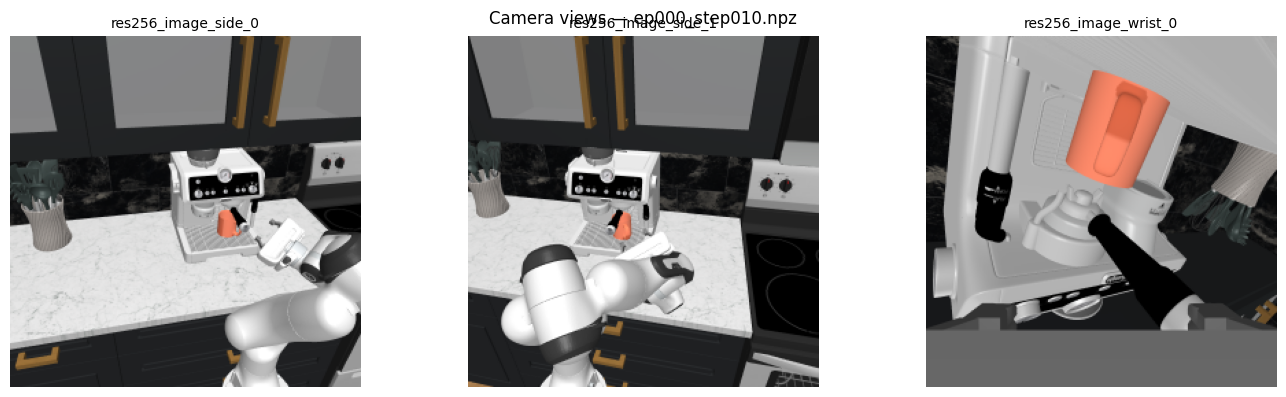

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)


Across all timesteps:
  x: mean=2.6243, 	var=0.0031, 	std=0.0516, 	range=0.3006
  y: mean=1.0387, 	var=0.0039, 	std=0.0571, 	range=0.2934
  z: mean=-1.7029, 	var=0.0021, 	std=0.0409, 	range=0.2009
Across final timestep only:
  x: mean=5.0635, 	var=0.0061, 	std=0.0784, 	range=0.5352
  y: mean=1.4611, 	var=0.0108, 	std=0.1041, 	range=0.5761
  z: mean=-3.0722, 	var=0.0078, 	std=0.0884, 	range=0.4404
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.01743, 	var=2.257e-05, 	std=0.004751, 	range=0.02372
  y: mean=0.01644, 	var=1.688e-05, 	std=0.004109, 	range=0.02009
  z: mean=0.01359, 	var=1.162e-05, 	std=0.003408, 	range=0.01622
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.01637, 	var=0.0001659, 	std=0.01288, 	range=0.05273
  y: mean=0.01921, 	var=0.0002095, 	std=0.01447, 	range=0.06055
  z: mean=0.01647, 	var=0.0001527, 	std=0.01236, 	range=0.05762
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.03898, 

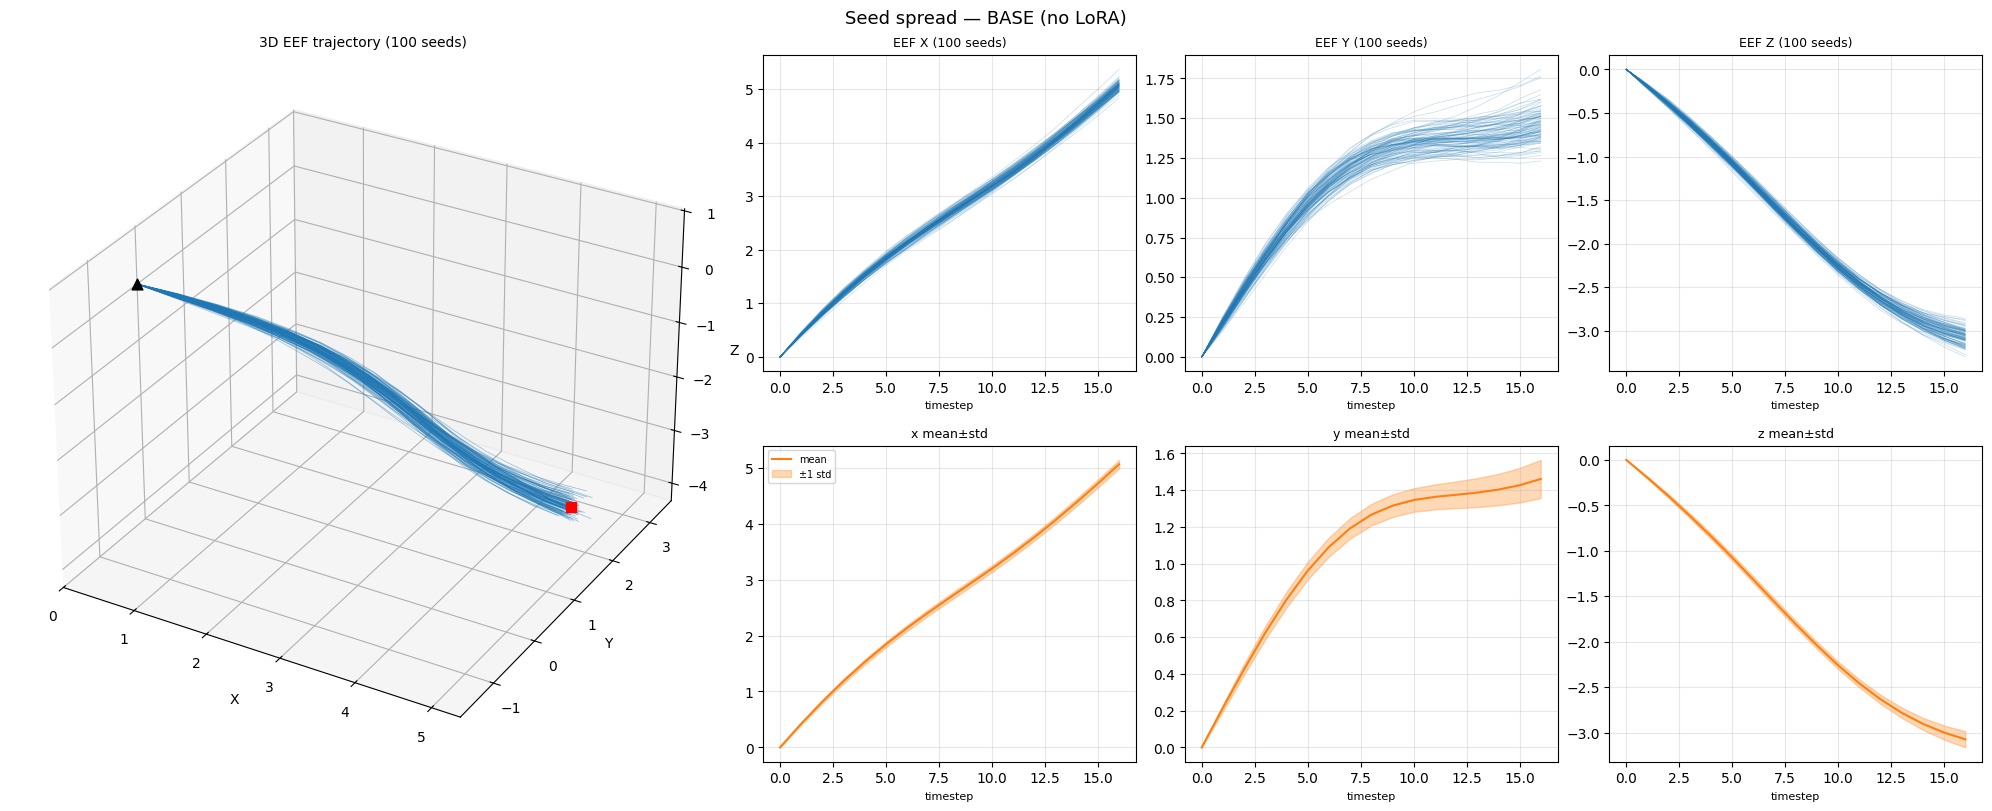


CHECKPOINT: old-target it17


  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017


Across all timesteps:
  x: mean=3.4730, 	var=0.1782, 	std=0.3871, 	range=2.1110
  y: mean=1.4234, 	var=0.1469, 	std=0.3471, 	range=1.9758
  z: mean=-2.1816, 	var=0.0880, 	std=0.2721, 	range=1.4604
Across final timestep only:
  x: mean=6.4384, 	var=0.3860, 	std=0.6213, 	range=4.0547
  y: mean=1.9766, 	var=0.3650, 	std=0.6041, 	range=3.3960
  z: mean=-4.0352, 	var=0.2135, 	std=0.4621, 	range=2.5488
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.1939, 	var=0.002647, 	std=0.05145, 	range=0.2369
  y: mean=0.2046, 	var=0.002433, 	std=0.04933, 	range=0.2493
  z: mean=0.1797, 	var=0.002134, 	std=0.04619, 	range=0.2248
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.1855, 	var=0.01858, 	std=0.1363, 	range=0.4941
  y: mean=0.2158, 	var=0.02408, 	std=0.1552, 	range=0.6108
  z: mean=0.172, 	var=0.02117, 	std=0.1455, 	range=0.5479
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.3258, 	var=0.007797, 	std=0.0883, 	

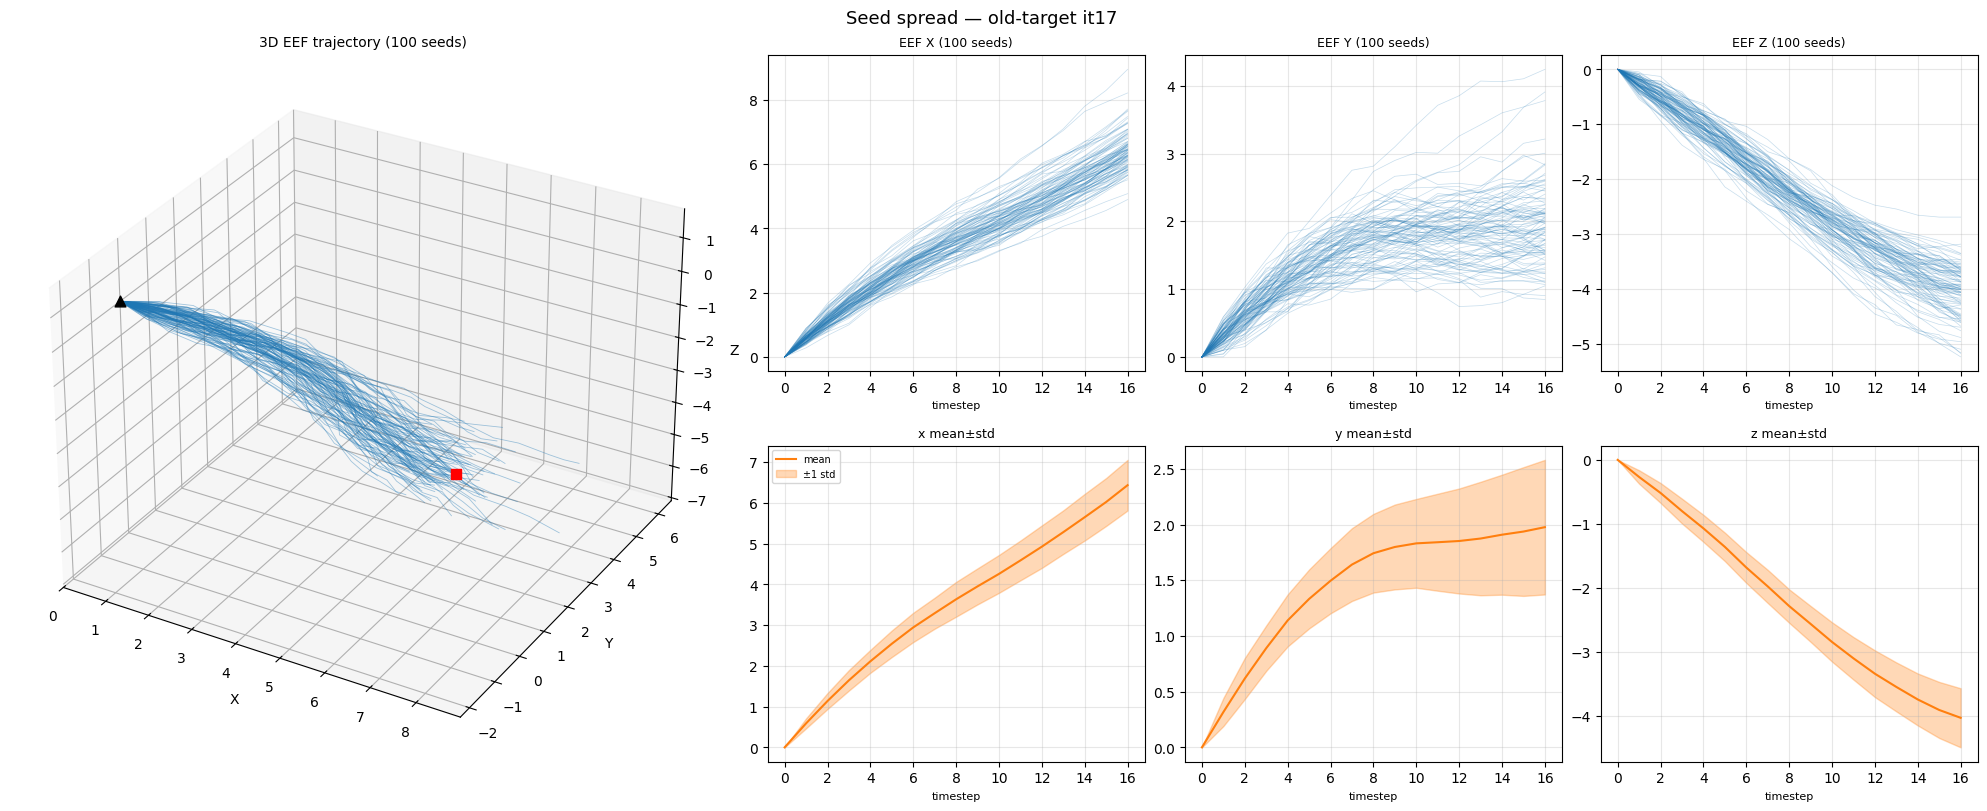


CHECKPOINT: fix p0.125 it05


  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2/iter_0005


Across all timesteps:
  x: mean=2.6377, 	var=0.0072, 	std=0.0786, 	range=0.4421
  y: mean=1.2940, 	var=0.0088, 	std=0.0843, 	range=0.4423
  z: mean=-1.7134, 	var=0.0045, 	std=0.0599, 	range=0.3128
Across final timestep only:
  x: mean=5.0642, 	var=0.0149, 	std=0.1219, 	range=0.8164
  y: mean=1.9119, 	var=0.0251, 	std=0.1583, 	range=0.8833
  z: mean=-3.1267, 	var=0.0143, 	std=0.1196, 	range=0.6211
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03517, 	var=9.093e-05, 	std=0.009536, 	range=0.04436
  y: mean=0.03347, 	var=7.442e-05, 	std=0.008627, 	range=0.04405
  z: mean=0.02579, 	var=4.449e-05, 	std=0.00667, 	range=0.03278
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.03338, 	var=0.000613, 	std=0.02476, 	range=0.09375
  y: mean=0.03629, 	var=0.0007927, 	std=0.02815, 	range=0.1169
  z: mean=0.02705, 	var=0.0005175, 	std=0.02275, 	range=0.09375
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.07673, 	va

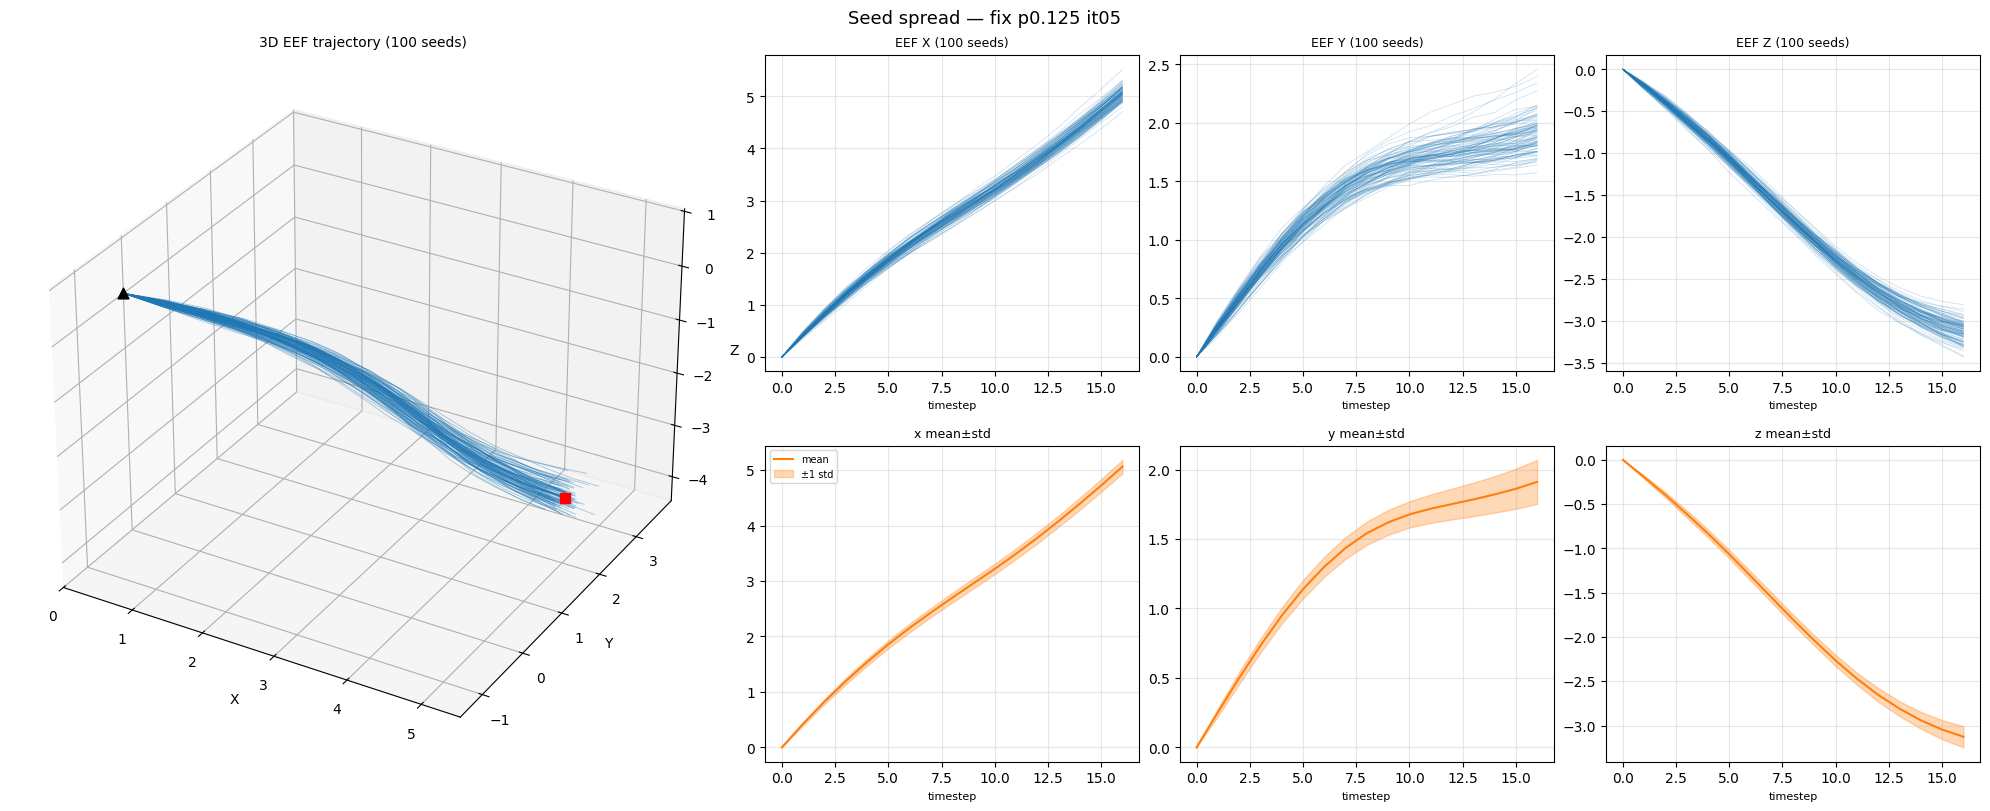


CHECKPOINT: fix p0.25 it05


  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0005


Across all timesteps:
  x: mean=2.6916, 	var=0.0065, 	std=0.0750, 	range=0.4251
  y: mean=1.2533, 	var=0.0075, 	std=0.0783, 	range=0.4107
  z: mean=-1.7189, 	var=0.0043, 	std=0.0593, 	range=0.3047
Across final timestep only:
  x: mean=5.1487, 	var=0.0132, 	std=0.1150, 	range=0.7773
  y: mean=1.8488, 	var=0.0211, 	std=0.1454, 	range=0.7982
  z: mean=-3.1520, 	var=0.0134, 	std=0.1157, 	range=0.6006
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03292, 	var=8.143e-05, 	std=0.009024, 	range=0.04367
  y: mean=0.03097, 	var=6.123e-05, 	std=0.007825, 	range=0.04116
  z: mean=0.02597, 	var=4.443e-05, 	std=0.006666, 	range=0.03122
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.03107, 	var=0.0005577, 	std=0.02362, 	range=0.08984
  y: mean=0.03377, 	var=0.0006327, 	std=0.02515, 	range=0.1057
  z: mean=0.02685, 	var=0.000482, 	std=0.02195, 	range=0.0918
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.07124, 	va

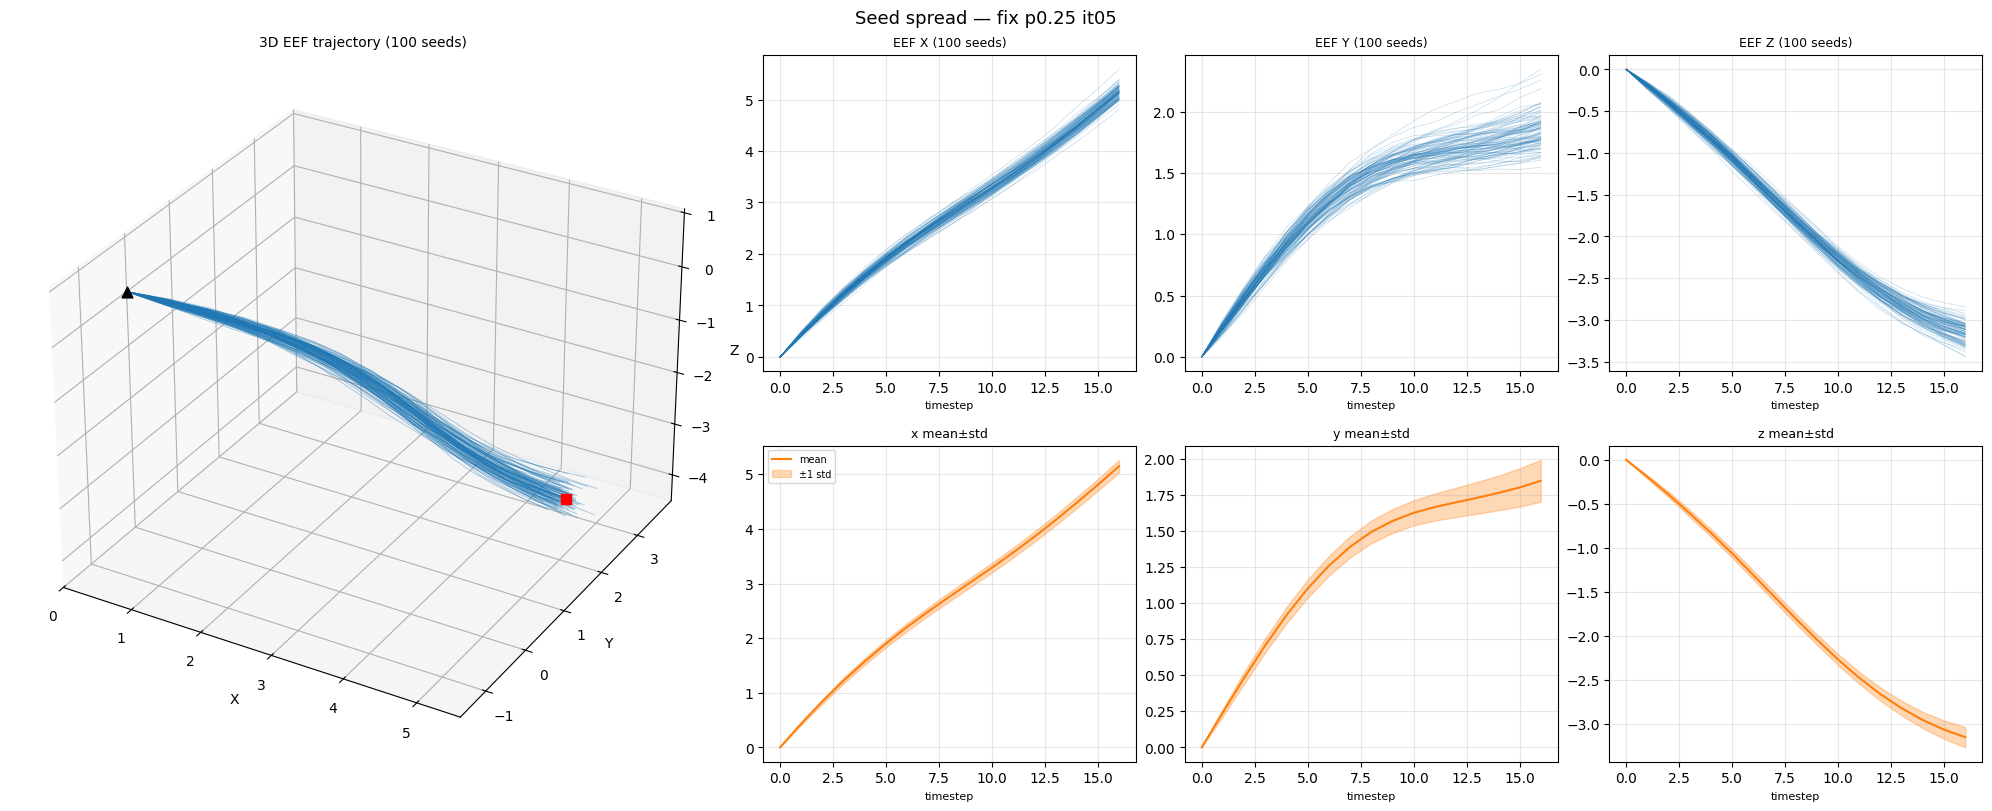


CHECKPOINT: fix p0.25 it06


  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0006


Across all timesteps:
  x: mean=2.6908, 	var=0.0058, 	std=0.0707, 	range=0.4000
  y: mean=1.2240, 	var=0.0066, 	std=0.0734, 	range=0.3885
  z: mean=-1.7325, 	var=0.0038, 	std=0.0552, 	range=0.2825
Across final timestep only:
  x: mean=5.1470, 	var=0.0119, 	std=0.1091, 	range=0.7324
  y: mean=1.7963, 	var=0.0189, 	std=0.1376, 	range=0.7568
  z: mean=-3.1786, 	var=0.0120, 	std=0.1094, 	range=0.5635
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.02956, 	var=6.714e-05, 	std=0.008194, 	range=0.03795
  y: mean=0.02698, 	var=4.799e-05, 	std=0.006927, 	range=0.03547
  z: mean=0.02314, 	var=3.478e-05, 	std=0.005898, 	range=0.02937
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.02801, 	var=0.0004813, 	std=0.02194, 	range=0.08594
  y: mean=0.02958, 	var=0.0005035, 	std=0.02244, 	range=0.09375
  z: mean=0.02448, 	var=0.0004027, 	std=0.02007, 	range=0.08594
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.06404, 

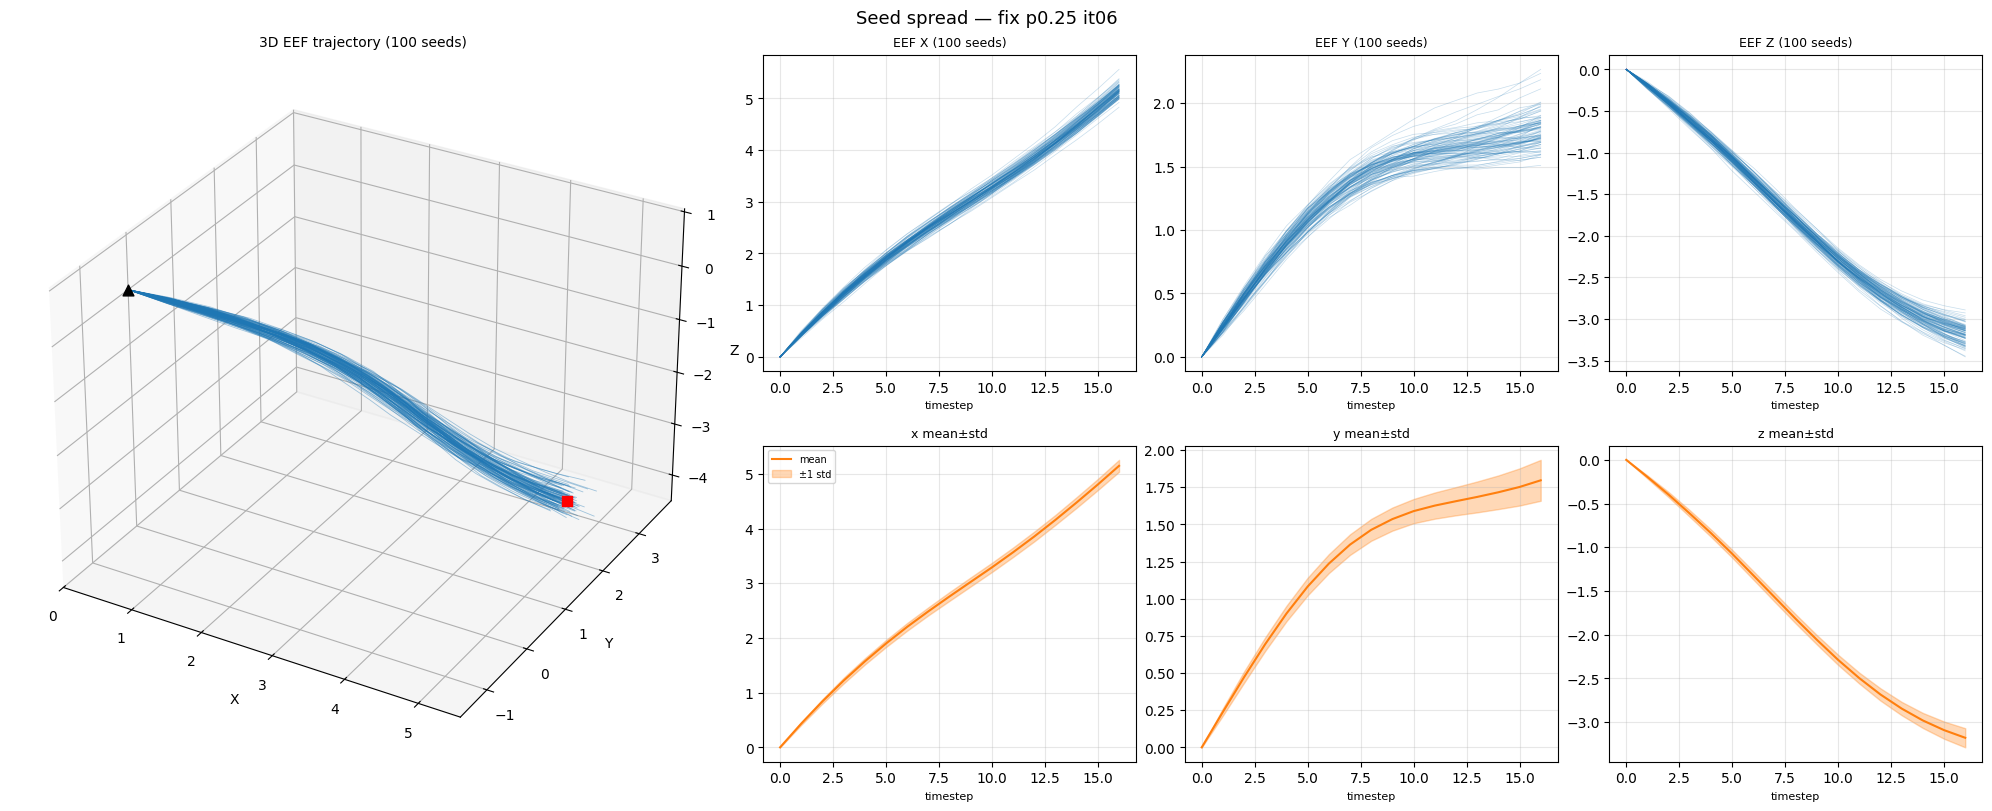


CHECKPOINT: fix p0.25 cap0.9 it08


  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPARD0.9/iter_0008


Across all timesteps:
  x: mean=2.6544, 	var=0.0059, 	std=0.0716, 	range=0.4075
  y: mean=1.3087, 	var=0.0064, 	std=0.0723, 	range=0.3797
  z: mean=-1.7247, 	var=0.0037, 	std=0.0544, 	range=0.2788
Across final timestep only:
  x: mean=5.0665, 	var=0.0121, 	std=0.1099, 	range=0.7441
  y: mean=1.9505, 	var=0.0186, 	std=0.1364, 	range=0.7449
  z: mean=-3.1640, 	var=0.0116, 	std=0.1078, 	range=0.5557
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03011, 	var=6.793e-05, 	std=0.008242, 	range=0.04018
  y: mean=0.02698, 	var=4.846e-05, 	std=0.006961, 	range=0.03617
  z: mean=0.02234, 	var=3.28e-05, 	std=0.005727, 	range=0.02689
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.02842, 	var=0.0004766, 	std=0.02183, 	range=0.08789
  y: mean=0.02965, 	var=0.0004876, 	std=0.02208, 	range=0.09448
  z: mean=0.02382, 	var=0.0003509, 	std=0.01873, 	range=0.08496
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.06549, 	

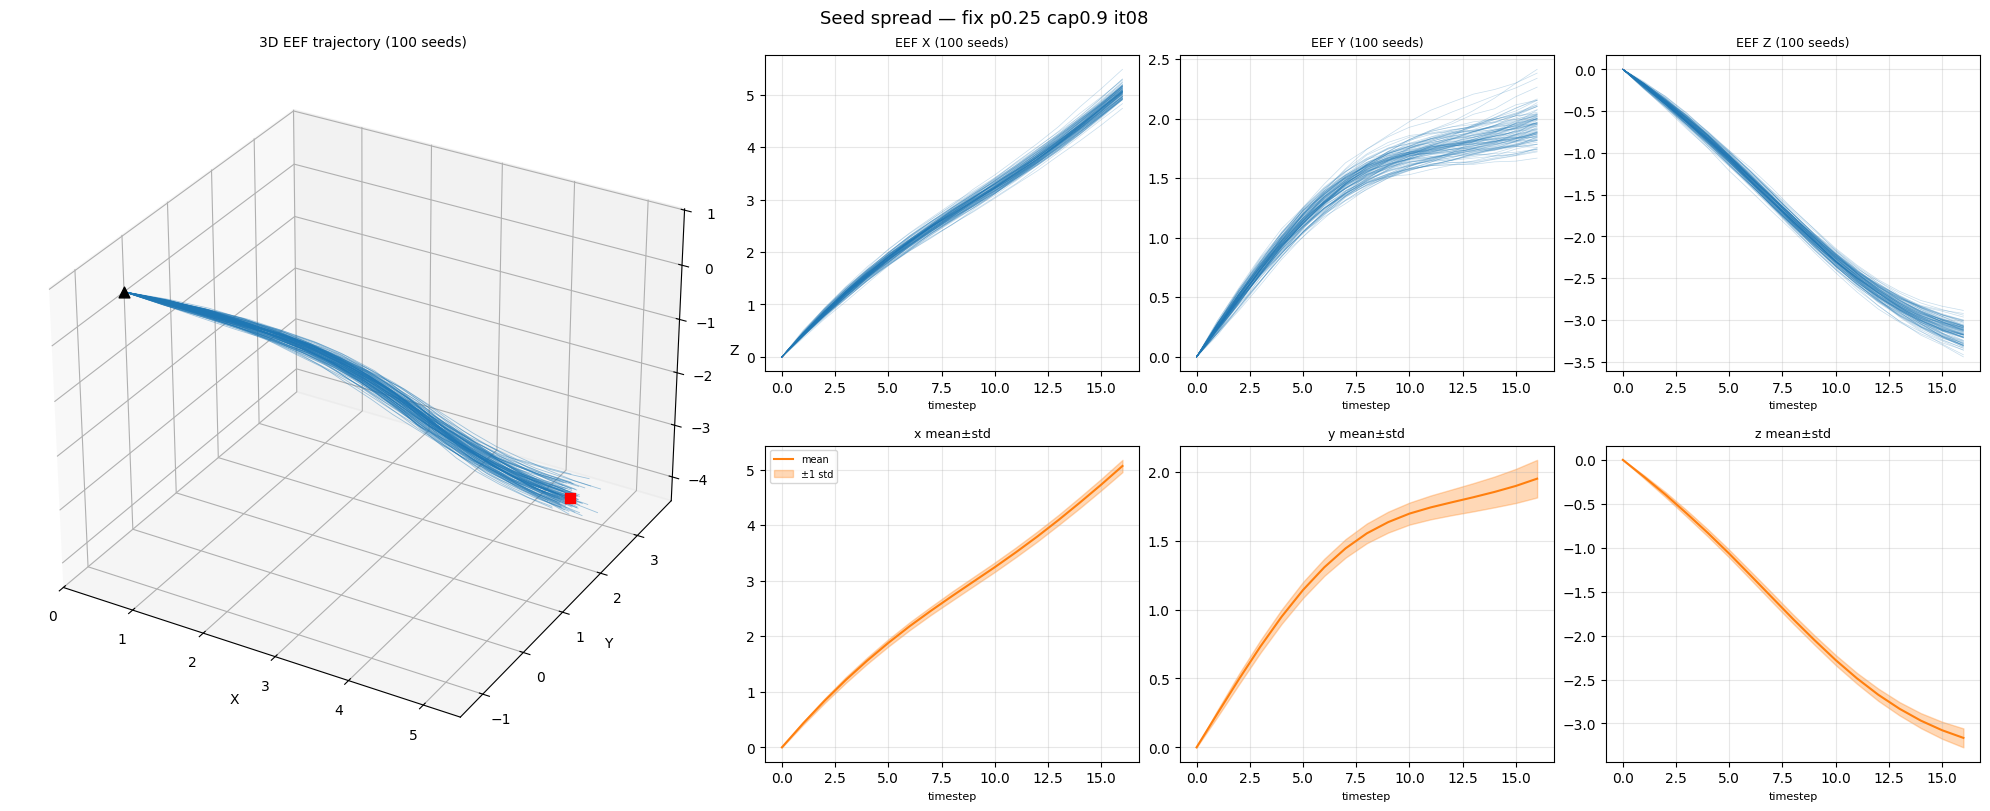


CHECKPOINT: fix p0.25 cap0.9 it09


  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPARD0.9/iter_0009


Across all timesteps:
  x: mean=2.6263, 	var=0.0055, 	std=0.0688, 	range=0.3936
  y: mean=1.3273, 	var=0.0064, 	std=0.0722, 	range=0.3787
  z: mean=-1.7347, 	var=0.0035, 	std=0.0527, 	range=0.2665
Across final timestep only:
  x: mean=5.0188, 	var=0.0111, 	std=0.1056, 	range=0.7109
  y: mean=1.9786, 	var=0.0188, 	std=0.1373, 	range=0.7432
  z: mean=-3.1921, 	var=0.0111, 	std=0.1053, 	range=0.5332
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.02815, 	var=5.793e-05, 	std=0.007611, 	range=0.03571
  y: mean=0.02579, 	var=4.255e-05, 	std=0.006523, 	range=0.03271
  z: mean=0.02094, 	var=2.787e-05, 	std=0.005279, 	range=0.02291
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.02715, 	var=0.0004413, 	std=0.02101, 	range=0.0918
  y: mean=0.02913, 	var=0.0005003, 	std=0.02237, 	range=0.1025
  z: mean=0.02341, 	var=0.000327, 	std=0.01808, 	range=0.08008
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.06136, 	va

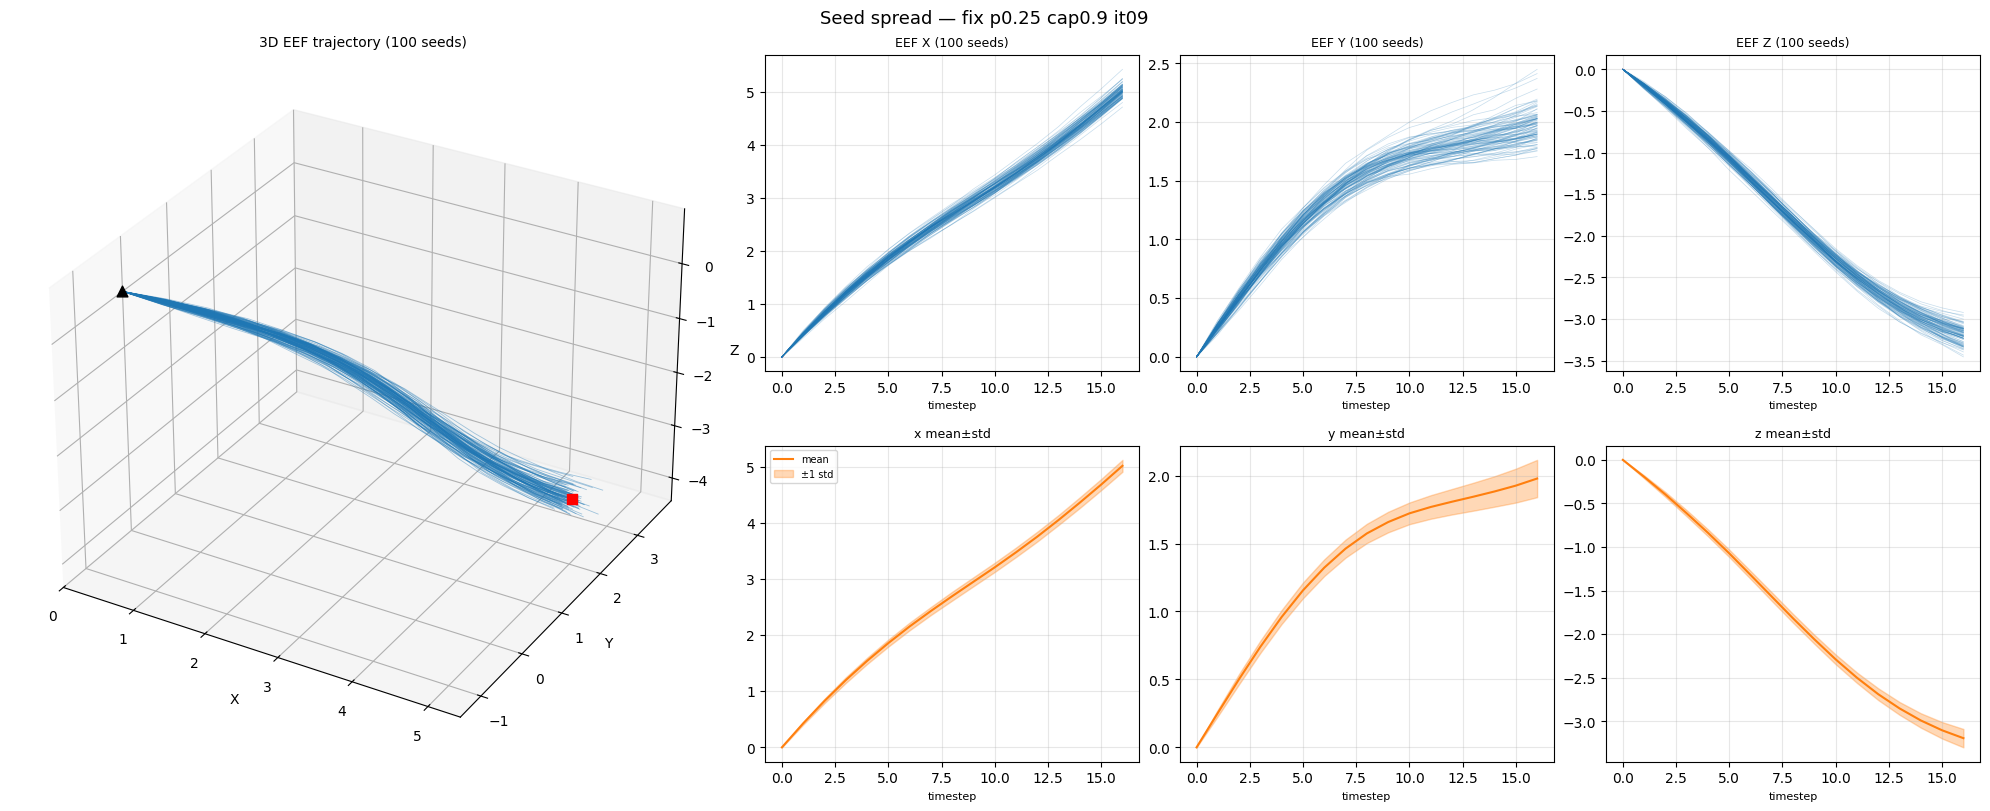

Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v4.5/seed_spread__ep000_step010.npz


In [6]:
# Cell 5: Run the full comparison (base model + all checkpoints) for OBS_PATH.
# OBS_PATH is set to ...ep000_step010.npz in Cell 1. Re-run with a different path for
# any other observation, e.g. analyze_all_checkpoints("/path/to/other.npz").
_features, results = analyze_all_checkpoints(OBS_PATH)

## Cross-checkpoint summary

Final-timestep EEF-position std across the seeds, per checkpoint (and the base model).
Higher std = more action diversity driven by the initial noise; lower std = the
checkpoint has become more "decisive" / peaked for this observation.

checkpoint                                              std_x    std_y    std_z      mean
BASE (no LoRA)                                         0.0784   0.1041   0.0884    0.0903
old-target it17                                        0.6213   0.6041   0.4621    0.5625
fix p0.125 it05                                        0.1219   0.1583   0.1196    0.1333
fix p0.25 it05                                         0.1150   0.1454   0.1157    0.1254
fix p0.25 it06                                         0.1091   0.1376   0.1094    0.1187
fix p0.25 cap0.9 it08                                  0.1099   0.1364   0.1078    0.1181
fix p0.25 cap0.9 it09                                  0.1056   0.1373   0.1053    0.1161


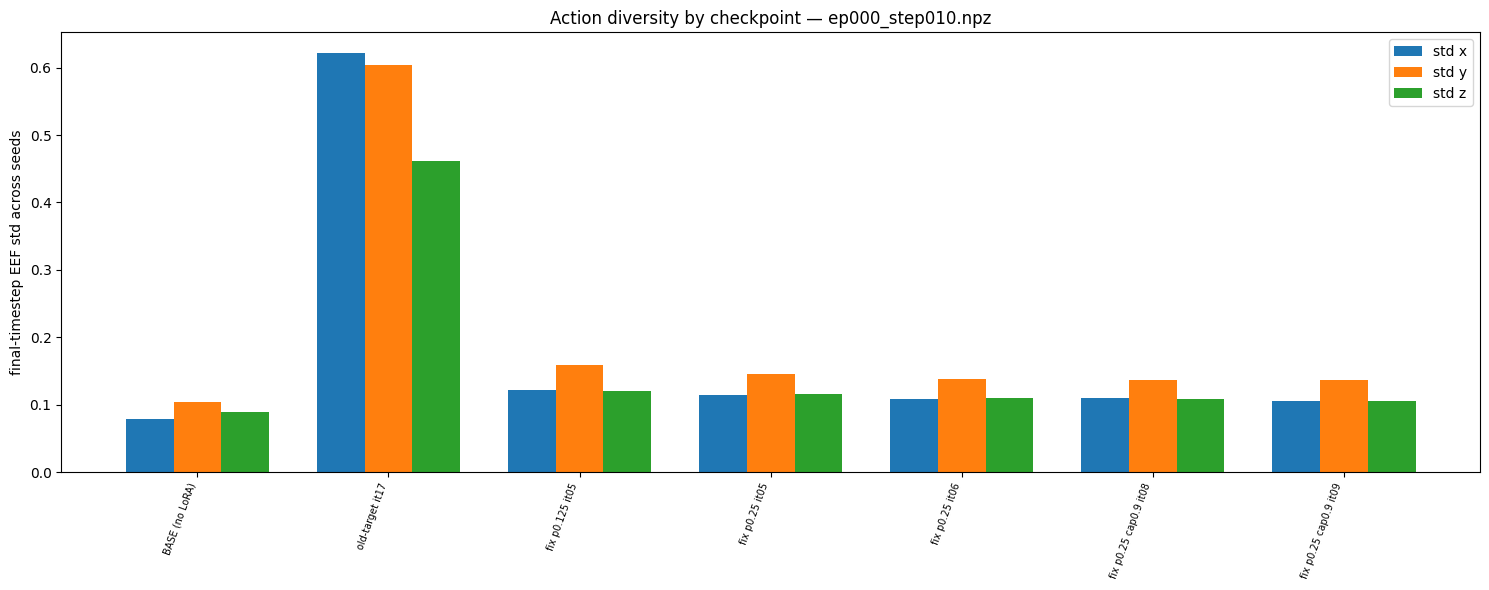

In [7]:
# Cell 6: Cross-checkpoint summary — final-timestep EEF position std across seeds.
labels_short = list(results.keys())
final_std = np.array([results[k]["final_std"] for k in labels_short])  # (n_ckpt, 3)

print(f"{'checkpoint':52s} {'std_x':>8s} {'std_y':>8s} {'std_z':>8s} {'mean':>9s}")
for k, fs in zip(labels_short, final_std):
    print(f"{k:52s} {fs[0]:8.4f} {fs[1]:8.4f} {fs[2]:8.4f} {fs.mean():9.4f}")

x = np.arange(len(labels_short))
w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
for i, l in enumerate(["x", "y", "z"]):
    ax.bar(x + (i - 1) * w, final_std[:, i], w, label=f"std {l}")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=70, ha="right", fontsize=7)
ax.set_ylabel("final-timestep EEF std across seeds")
ax.set_title(f"Action diversity by checkpoint — {os.path.basename(OBS_PATH)}")
ax.legend()
plt.tight_layout()
plt.show()

Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)


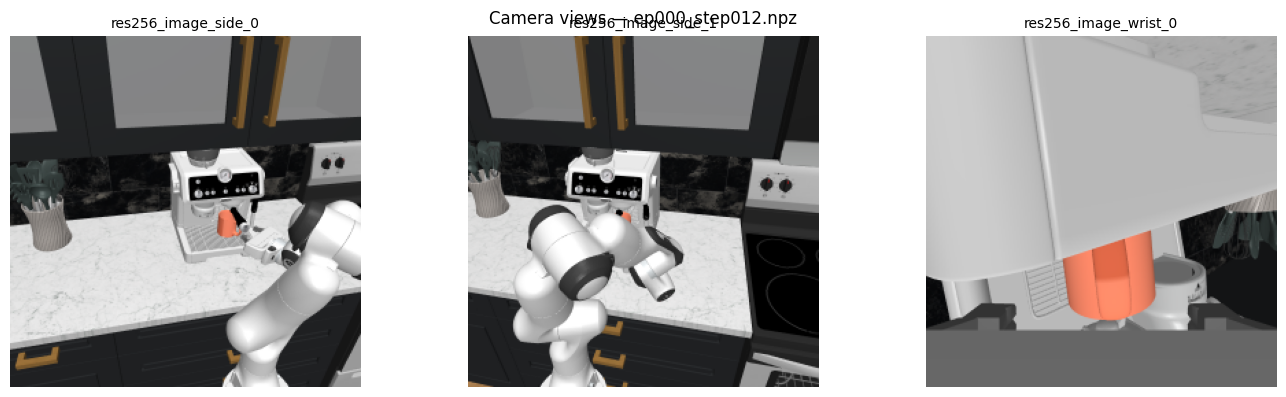

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)


Across all timesteps:
  x: mean=1.6897, 	var=0.0023, 	std=0.0455, 	range=0.2434
  y: mean=0.6733, 	var=0.0234, 	std=0.1338, 	range=0.7270
  z: mean=-0.2346, 	var=0.0117, 	std=0.0873, 	range=0.4611
Across final timestep only:
  x: mean=3.0560, 	var=0.0046, 	std=0.0682, 	range=0.4199
  y: mean=1.4409, 	var=0.0742, 	std=0.2724, 	range=1.6533
  z: mean=-0.8299, 	var=0.0518, 	std=0.2277, 	range=1.2935
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.01794, 	var=2.481e-05, 	std=0.004981, 	range=0.02504
  y: mean=0.0164, 	var=1.666e-05, 	std=0.004082, 	range=0.01908
  z: mean=0.01383, 	var=1.177e-05, 	std=0.003431, 	range=0.01843
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.01591, 	var=0.0001549, 	std=0.01245, 	range=0.05078
  y: mean=0.01801, 	var=0.0001964, 	std=0.01401, 	range=0.06152
  z: mean=0.01226, 	var=0.0001169, 	std=0.01081, 	range=0.0459
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.06949, 	v

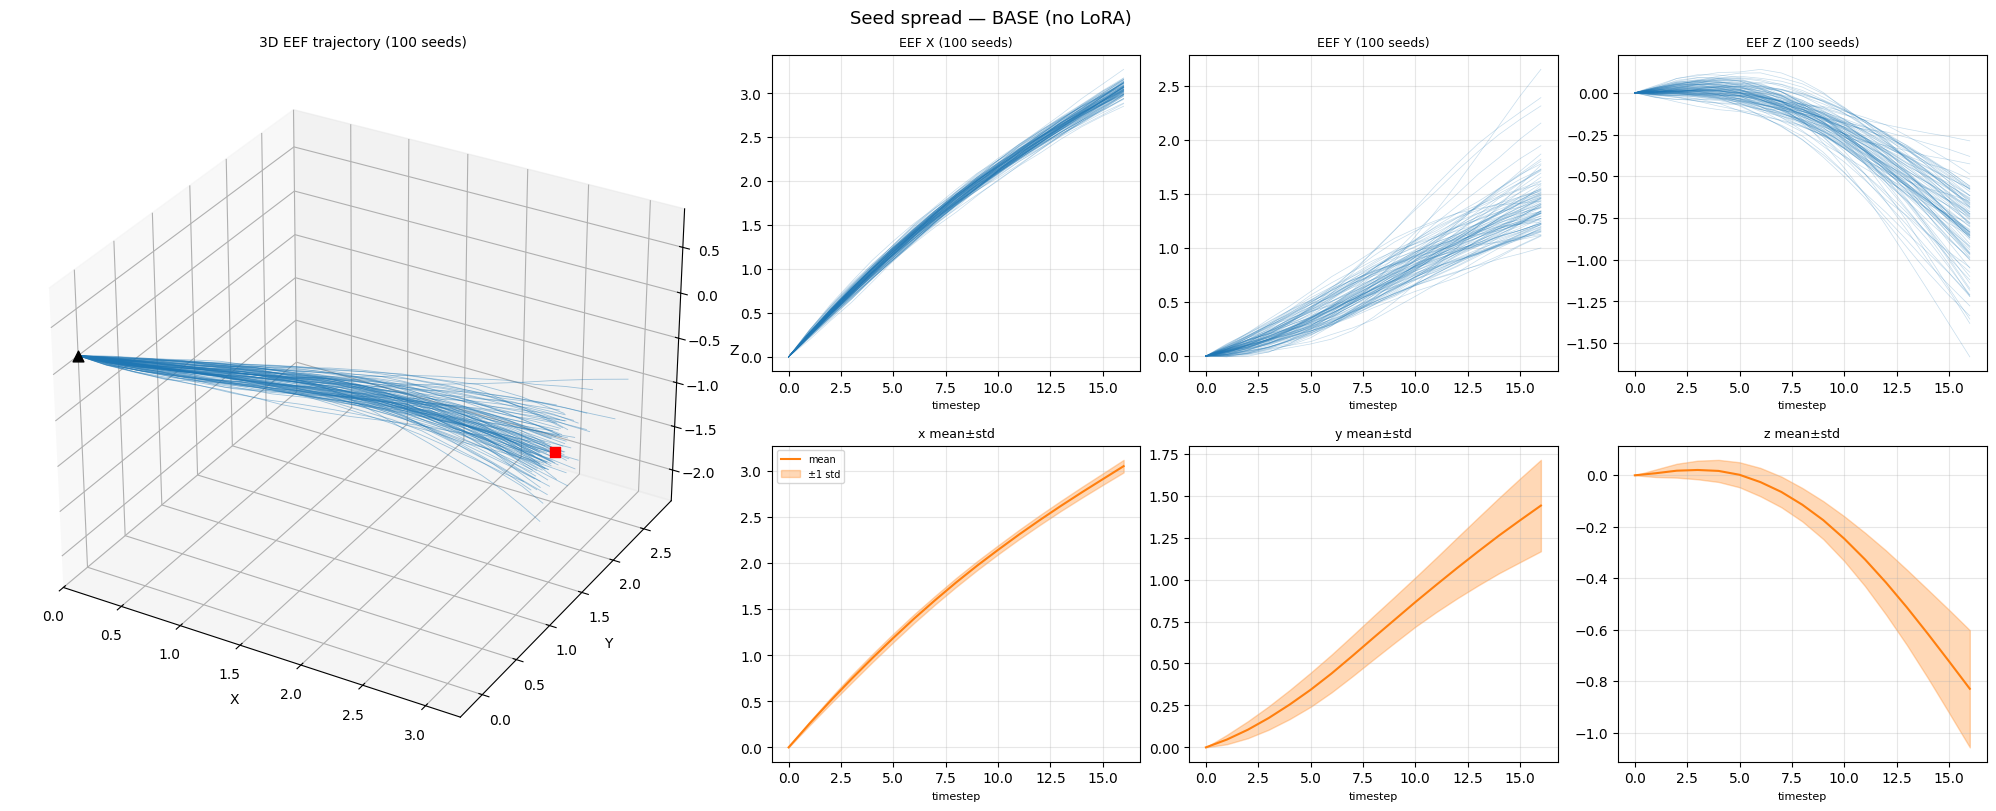


CHECKPOINT: old-target it17
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017


Across all timesteps:
  x: mean=2.1127, 	var=0.1306, 	std=0.3273, 	range=1.8786
  y: mean=1.0752, 	var=0.3806, 	std=0.5305, 	range=3.1200
  z: mean=-0.6087, 	var=0.1653, 	std=0.3515, 	range=1.9444
Across final timestep only:
  x: mean=3.9477, 	var=0.3125, 	std=0.5590, 	range=3.6924
  y: mean=2.3439, 	var=1.2323, 	std=1.1101, 	range=6.4194
  z: mean=-1.7672, 	var=0.5441, 	std=0.7376, 	range=4.4266
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.1968, 	var=0.002653, 	std=0.0515, 	range=0.2377
  y: mean=0.2232, 	var=0.002872, 	std=0.0536, 	range=0.2686
  z: mean=0.1839, 	var=0.002144, 	std=0.0463, 	range=0.2271
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.1995, 	var=0.02059, 	std=0.1435, 	range=0.5195
  y: mean=0.2474, 	var=0.0323, 	std=0.1797, 	range=0.7861
  z: mean=0.1817, 	var=0.02399, 	std=0.1549, 	range=0.6045
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.4929, 	var=0.02242, 	std=0.1497, 	rang

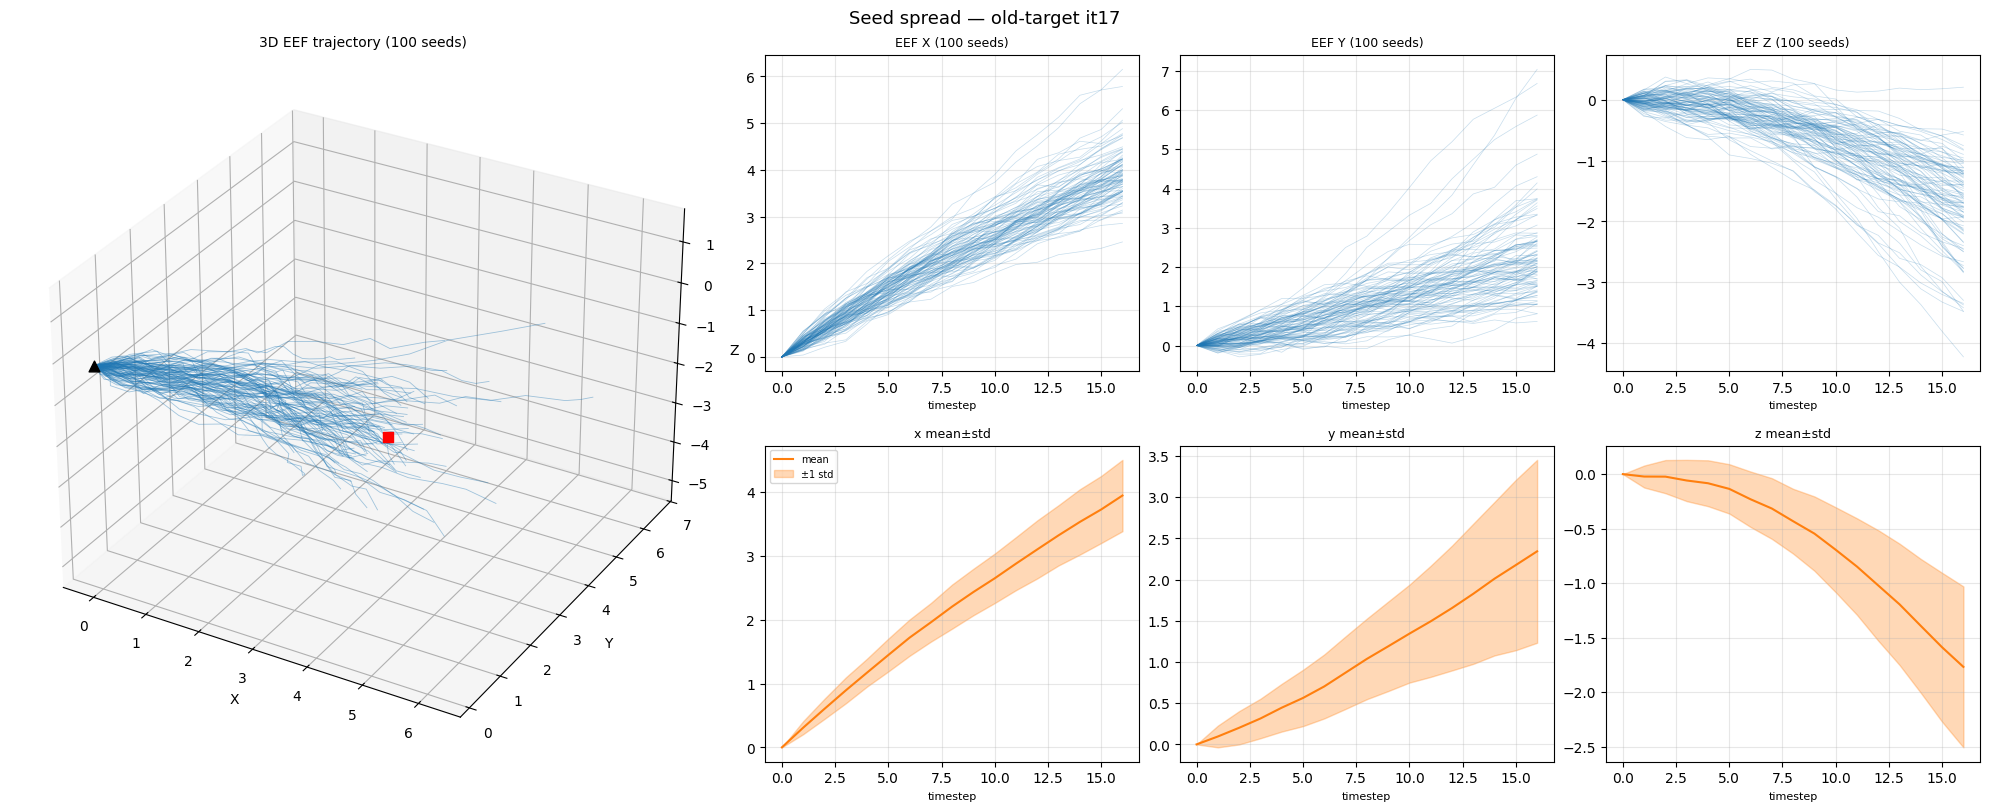


CHECKPOINT: fix p0.125 it05
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2/iter_0005


Across all timesteps:
  x: mean=1.6297, 	var=0.0069, 	std=0.0776, 	range=0.4153
  y: mean=0.8425, 	var=0.0459, 	std=0.1855, 	range=1.0180
  z: mean=-0.3081, 	var=0.0230, 	std=0.1236, 	range=0.6584
Across final timestep only:
  x: mean=2.9281, 	var=0.0146, 	std=0.1209, 	range=0.7793
  y: mean=1.7564, 	var=0.1491, 	std=0.3861, 	range=2.3275
  z: mean=-1.0153, 	var=0.0948, 	std=0.3080, 	range=1.7427
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.0377, 	var=0.0001051, 	std=0.01025, 	range=0.05036
  y: mean=0.03587, 	var=8.416e-05, 	std=0.009174, 	range=0.04592
  z: mean=0.02845, 	var=5.128e-05, 	std=0.007161, 	range=0.03678
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.03537, 	var=0.0006779, 	std=0.02604, 	range=0.1035
  y: mean=0.03796, 	var=0.0009514, 	std=0.03085, 	range=0.1396
  z: mean=0.02657, 	var=0.0005436, 	std=0.02332, 	range=0.09082
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1414, 	var=

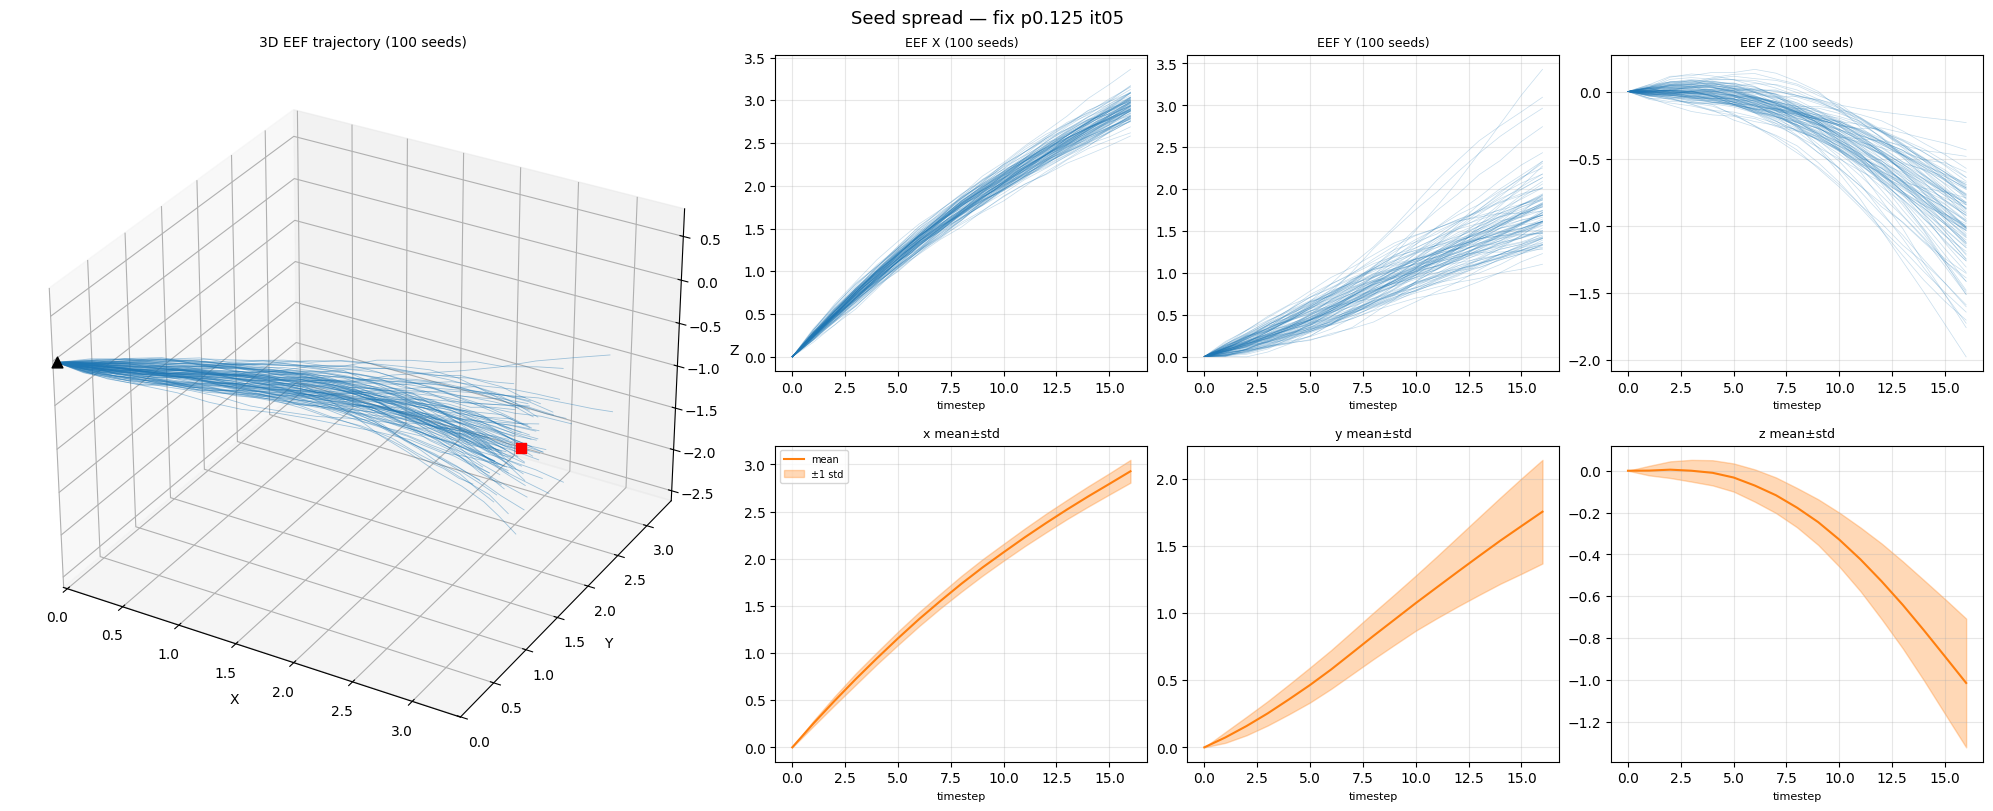


CHECKPOINT: fix p0.25 it05
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0005


Across all timesteps:
  x: mean=1.6395, 	var=0.0060, 	std=0.0721, 	range=0.3874
  y: mean=0.8631, 	var=0.0439, 	std=0.1815, 	range=1.0058
  z: mean=-0.3001, 	var=0.0227, 	std=0.1232, 	range=0.6507
Across final timestep only:
  x: mean=2.9560, 	var=0.0123, 	std=0.1110, 	range=0.7085
  y: mean=1.7569, 	var=0.1427, 	std=0.3778, 	range=2.2941
  z: mean=-0.9786, 	var=0.0918, 	std=0.3030, 	range=1.6724
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03591, 	var=9.618e-05, 	std=0.009807, 	range=0.04604
  y: mean=0.03382, 	var=7.106e-05, 	std=0.00843, 	range=0.04262
  z: mean=0.02846, 	var=4.95e-05, 	std=0.007036, 	range=0.03373
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.03365, 	var=0.0006612, 	std=0.02571, 	range=0.1016
  y: mean=0.03649, 	var=0.0008131, 	std=0.02852, 	range=0.1211
  z: mean=0.02672, 	var=0.0005187, 	std=0.02278, 	range=0.08789
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1348, 	var=

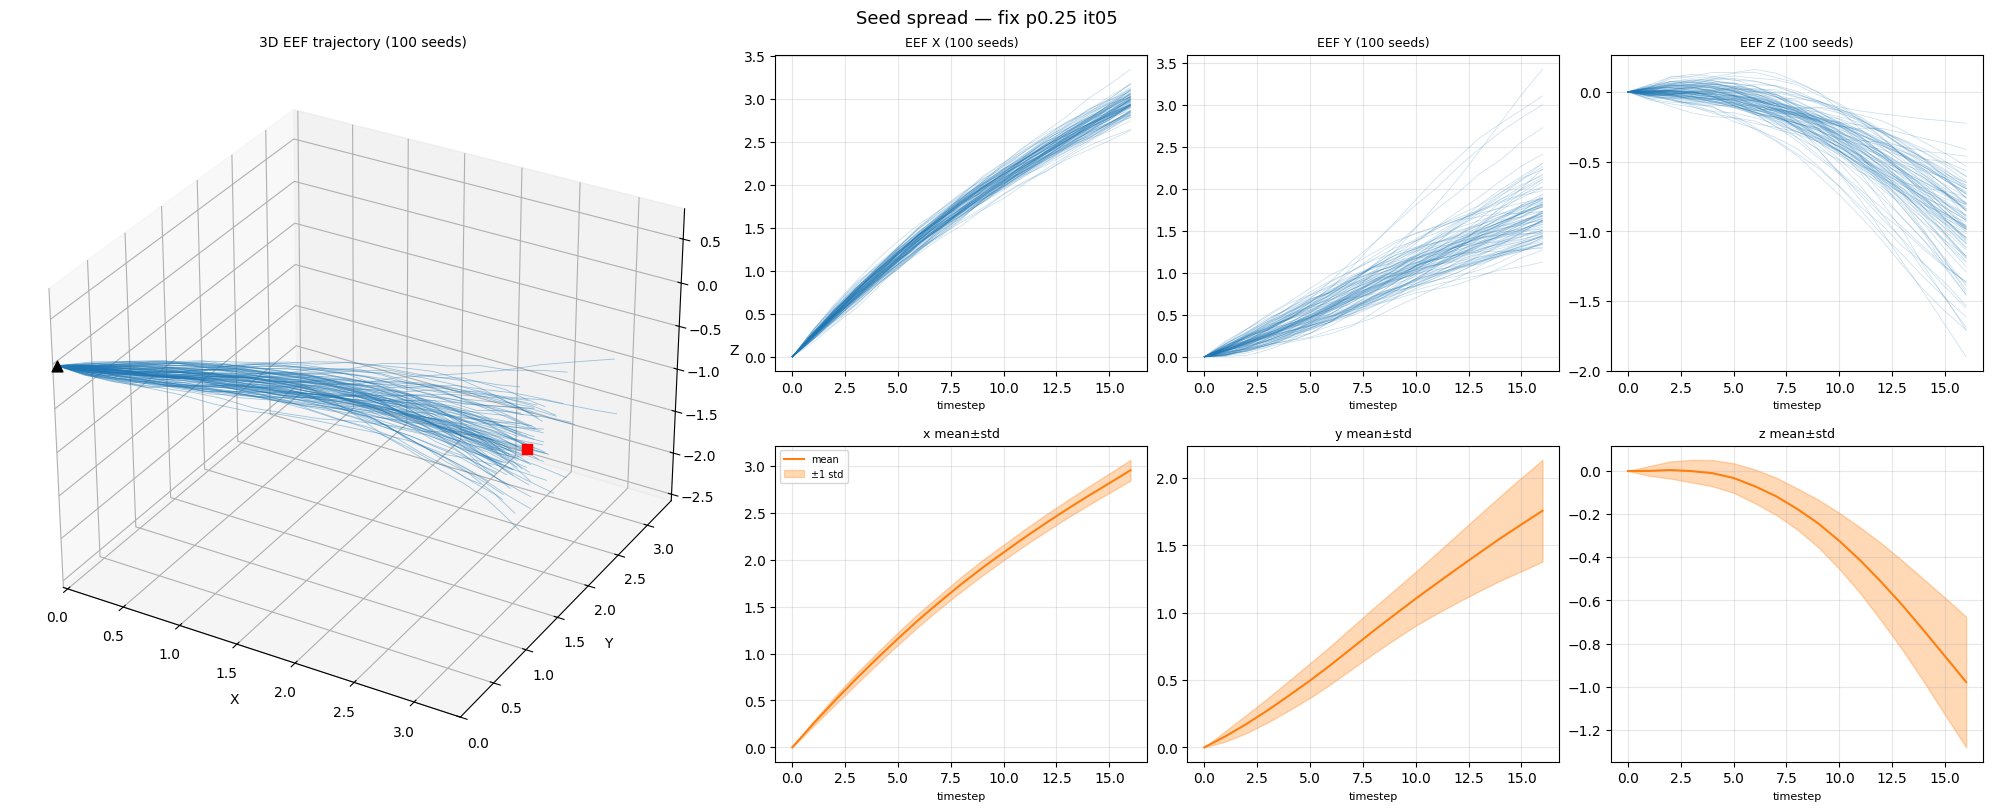


CHECKPOINT: fix p0.25 it06
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0006


Across all timesteps:
  x: mean=1.6307, 	var=0.0056, 	std=0.0697, 	range=0.3697
  y: mean=0.8533, 	var=0.0440, 	std=0.1804, 	range=1.0012
  z: mean=-0.3107, 	var=0.0240, 	std=0.1256, 	range=0.6722
Across final timestep only:
  x: mean=2.9219, 	var=0.0119, 	std=0.1090, 	range=0.6816
  y: mean=1.7424, 	var=0.1462, 	std=0.3824, 	range=2.2751
  z: mean=-1.0305, 	var=0.0983, 	std=0.3135, 	range=1.7104
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03264, 	var=7.971e-05, 	std=0.008928, 	range=0.04269
  y: mean=0.03001, 	var=5.824e-05, 	std=0.007631, 	range=0.03714
  z: mean=0.02547, 	var=4.012e-05, 	std=0.006334, 	range=0.03127
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.03047, 	var=0.0005384, 	std=0.0232, 	range=0.09766
  y: mean=0.03279, 	var=0.000657, 	std=0.02563, 	range=0.1104
  z: mean=0.02403, 	var=0.0004278, 	std=0.02068, 	range=0.07812
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1229, 	var

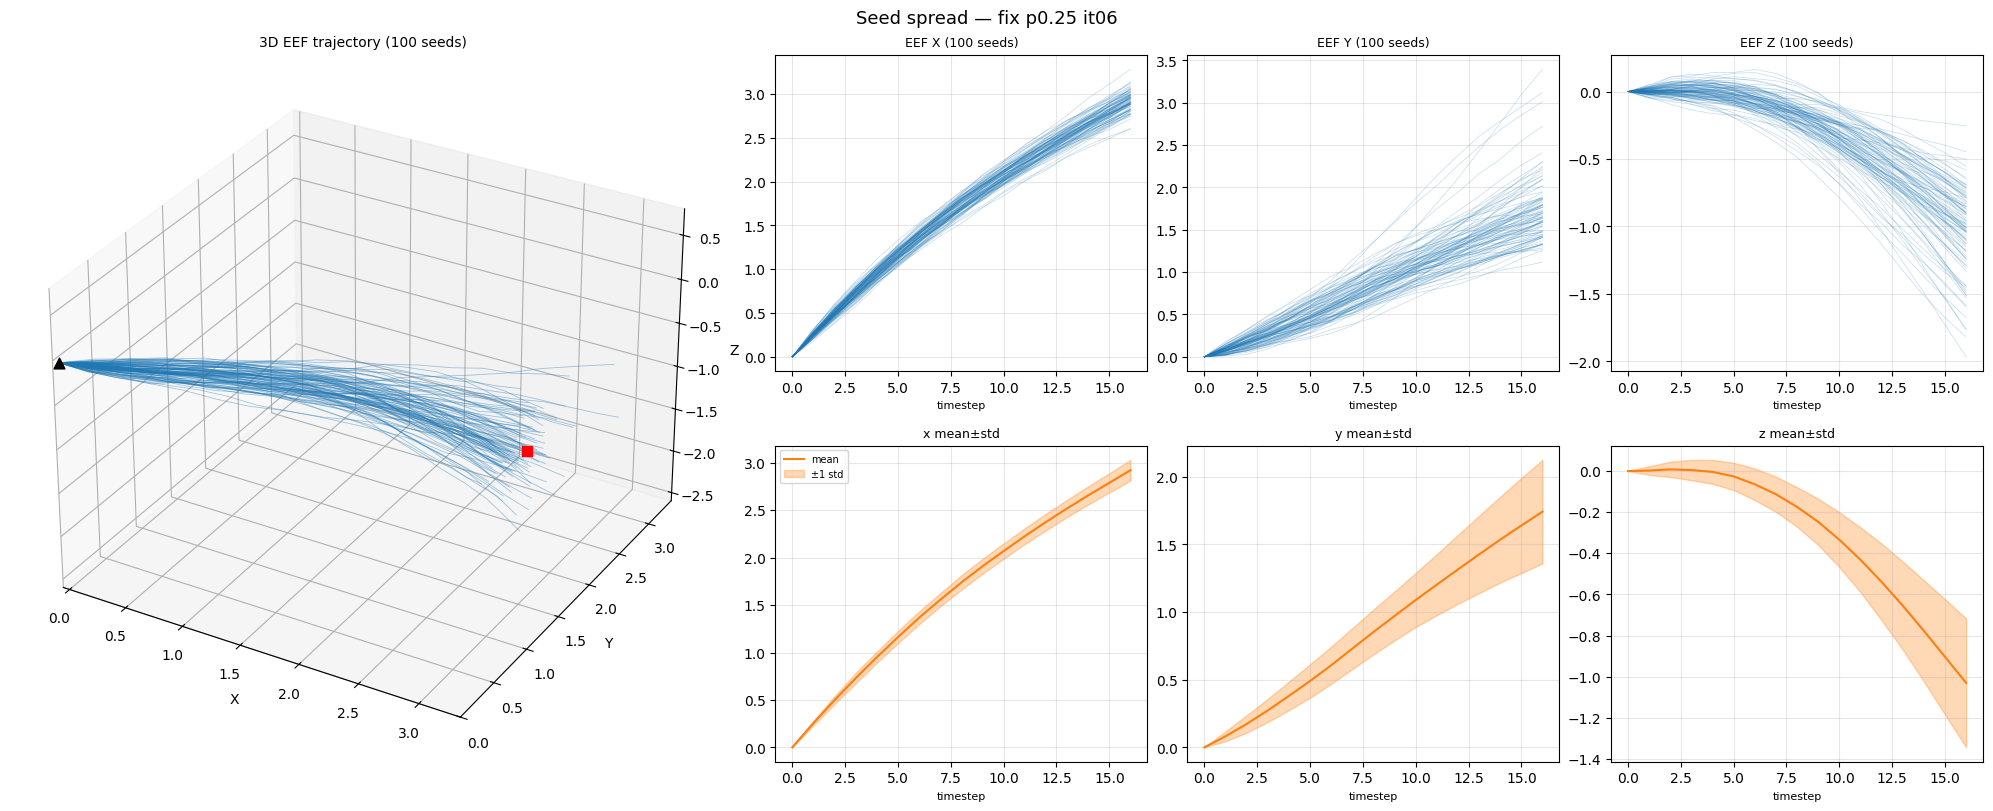


CHECKPOINT: fix p0.25 cap0.9 it08
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPARD0.9/iter_0008


Across all timesteps:
  x: mean=1.6005, 	var=0.0060, 	std=0.0722, 	range=0.3757
  y: mean=0.9055, 	var=0.0467, 	std=0.1864, 	range=1.0245
  z: mean=-0.2853, 	var=0.0247, 	std=0.1270, 	range=0.6853
Across final timestep only:
  x: mean=2.8487, 	var=0.0127, 	std=0.1127, 	range=0.6826
  y: mean=1.8171, 	var=0.1530, 	std=0.3912, 	range=2.3245
  z: mean=-0.9954, 	var=0.1004, 	std=0.3169, 	range=1.6842
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03385, 	var=8.627e-05, 	std=0.009288, 	range=0.04461
  y: mean=0.03067, 	var=6.134e-05, 	std=0.007832, 	range=0.03823
  z: mean=0.02554, 	var=3.948e-05, 	std=0.006284, 	range=0.02963
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.03219, 	var=0.0006086, 	std=0.02467, 	range=0.1016
  y: mean=0.03382, 	var=0.0006756, 	std=0.02599, 	range=0.1108
  z: mean=0.02477, 	var=0.0004386, 	std=0.02094, 	range=0.08398
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1282, 	va

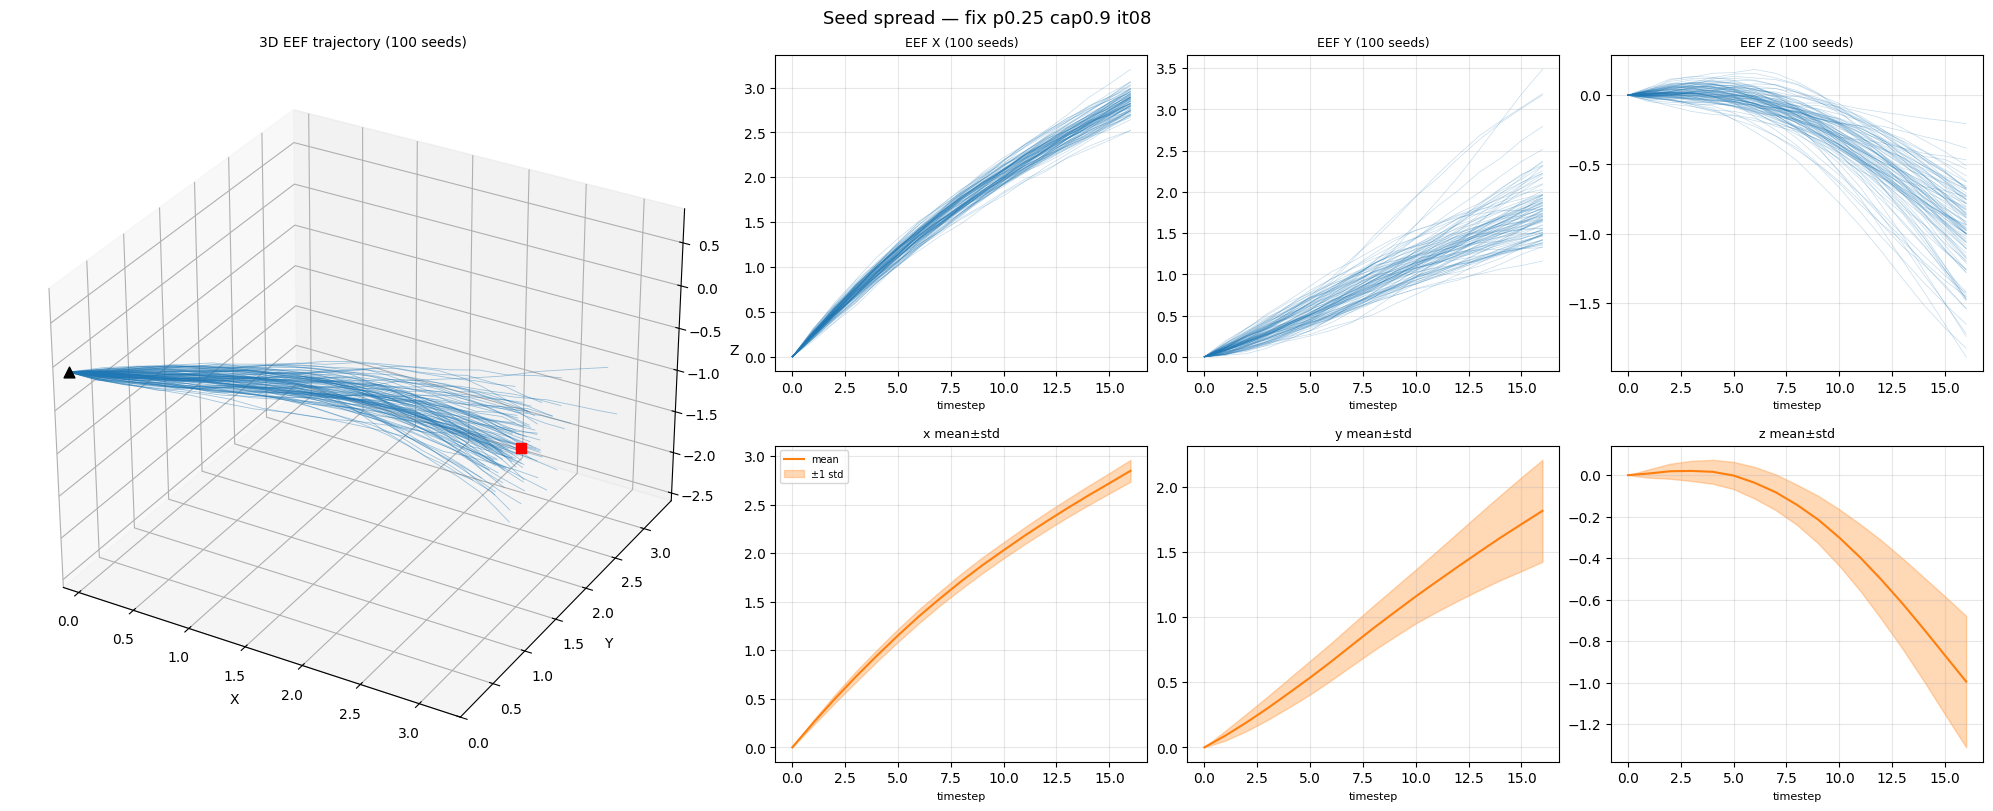


CHECKPOINT: fix p0.25 cap0.9 it09
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPARD0.9/iter_0009


Across all timesteps:
  x: mean=1.5659, 	var=0.0059, 	std=0.0714, 	range=0.3787
  y: mean=0.9698, 	var=0.0497, 	std=0.1914, 	range=1.0558
  z: mean=-0.3257, 	var=0.0255, 	std=0.1289, 	range=0.7032
Across final timestep only:
  x: mean=2.7863, 	var=0.0129, 	std=0.1137, 	range=0.7158
  y: mean=1.9148, 	var=0.1643, 	std=0.4053, 	range=2.3909
  z: mean=-1.0750, 	var=0.1032, 	std=0.3213, 	range=1.6963
Jerk |3rd diff of EEF path|, per-seed mean over all timesteps:
  x: mean=0.03286, 	var=7.896e-05, 	std=0.008886, 	range=0.04182
  y: mean=0.03021, 	var=5.995e-05, 	std=0.007743, 	range=0.03578
  z: mean=0.02514, 	var=3.727e-05, 	std=0.006105, 	range=0.02846
Jerk |3rd diff of EEF path|, final timestep only:
  x: mean=0.0312, 	var=0.0005769, 	std=0.02402, 	range=0.09961
  y: mean=0.03337, 	var=0.0006839, 	std=0.02615, 	range=0.1147
  z: mean=0.02454, 	var=0.0004157, 	std=0.02039, 	range=0.07812
Normalized jerk = sum|jerk| / path length, per seed (scale-free; 3D = pathjerk):
  x: mean=0.1239, 	va

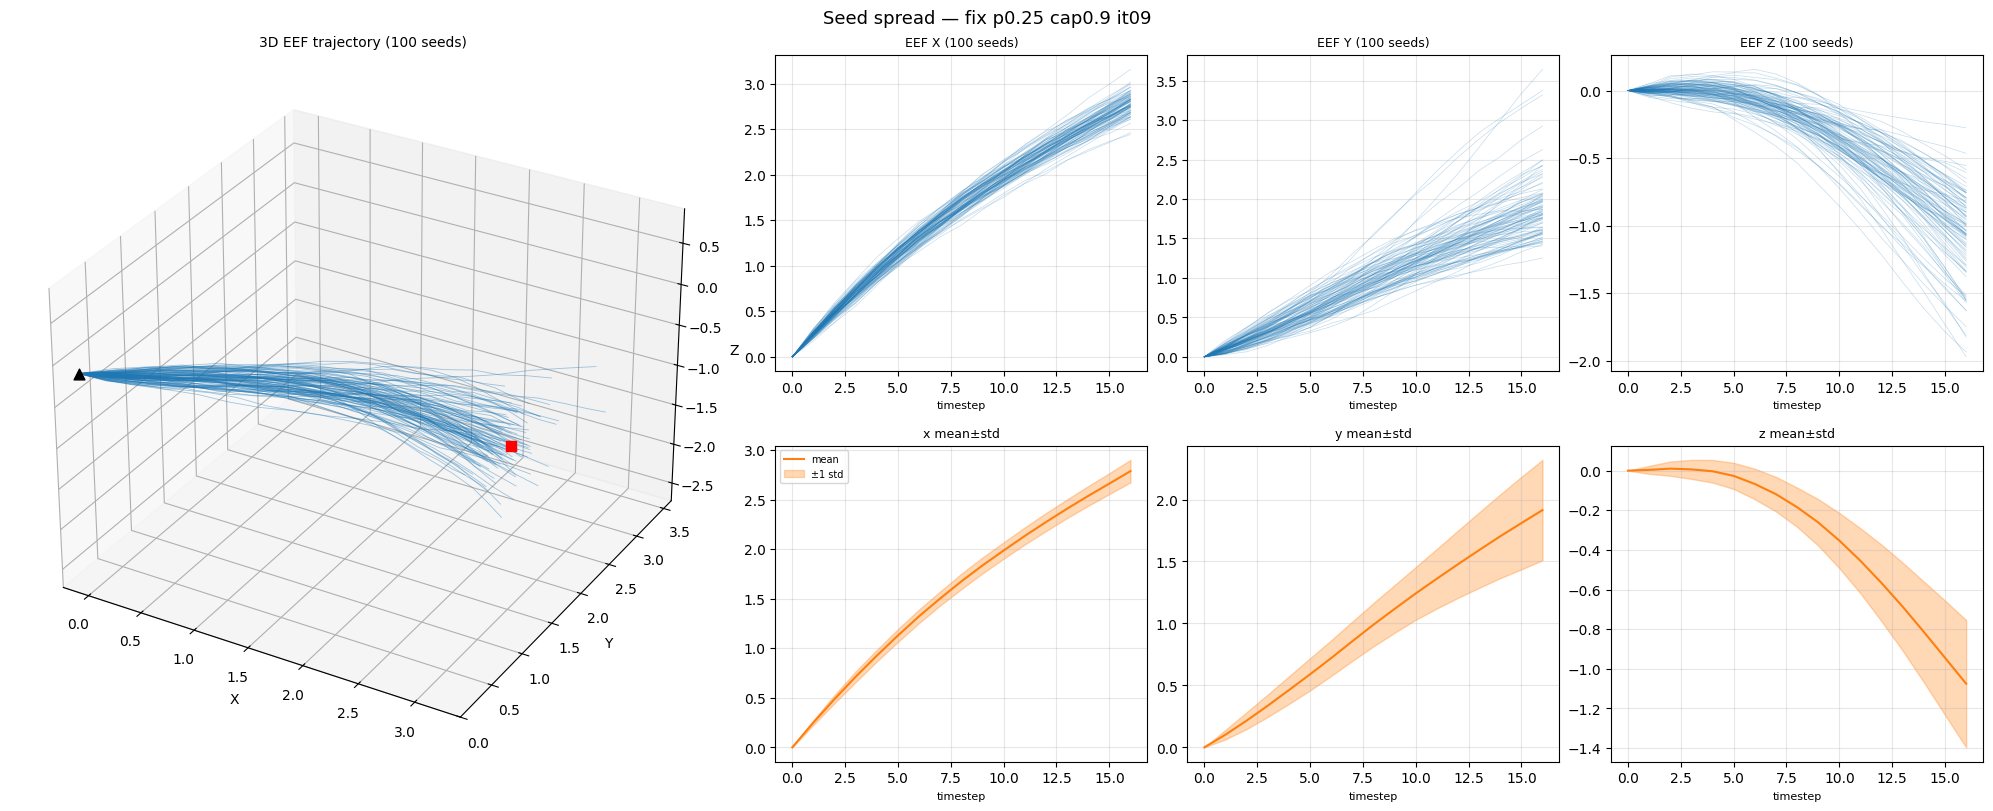

Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v4.5/seed_spread__ep000_step012.npz


In [8]:
# Cell 7: Re-run the full comparison for a different observation (step 012).
OBS_PATH = "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz"
_features, results = analyze_all_checkpoints(OBS_PATH)

checkpoint                                              std_x    std_y    std_z      mean
BASE (no LoRA)                                         0.0682   0.2724   0.2277    0.1894
old-target it17                                        0.5590   1.1101   0.7376    0.8022
fix p0.125 it05                                        0.1209   0.3861   0.3080    0.2716
fix p0.25 it05                                         0.1110   0.3778   0.3030    0.2639
fix p0.25 it06                                         0.1090   0.3824   0.3135    0.2683
fix p0.25 cap0.9 it08                                  0.1127   0.3912   0.3169    0.2736
fix p0.25 cap0.9 it09                                  0.1137   0.4053   0.3213    0.2801


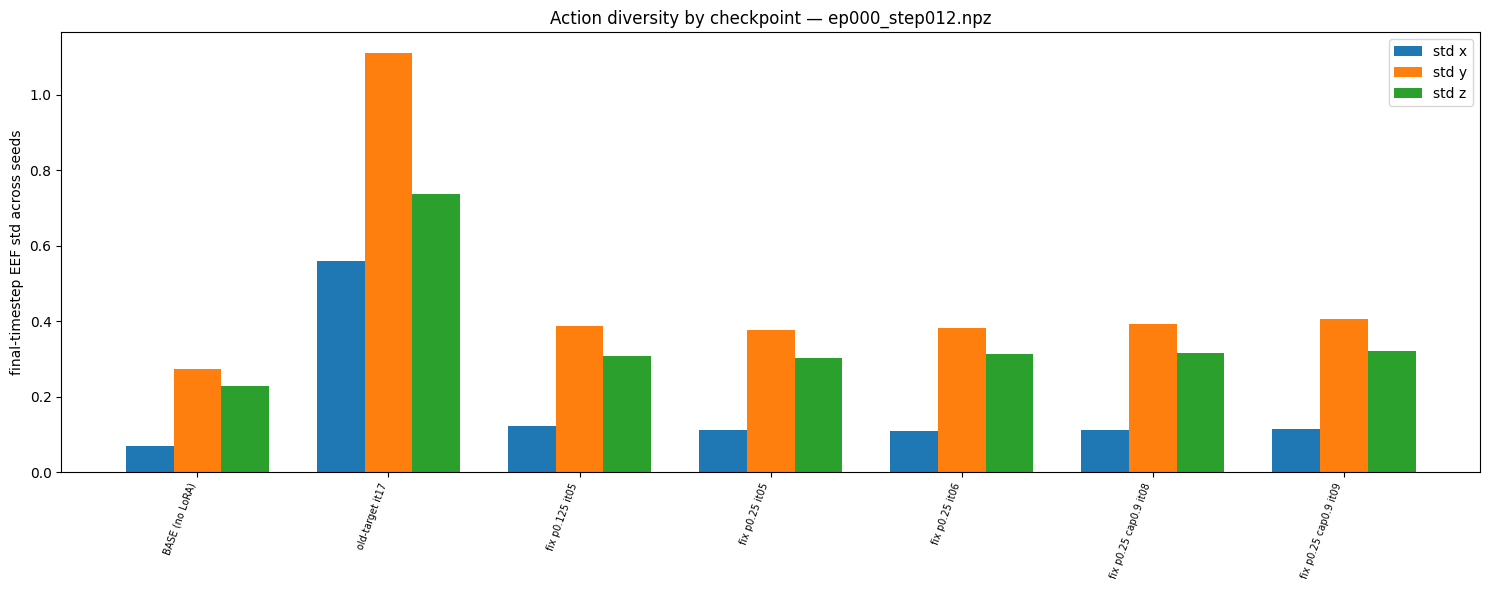

In [9]:
# Cell 8: Cross-checkpoint summary for the step-012 observation
# (identical to Cell 6, re-run against the results from the cell above).
labels_short = list(results.keys())
final_std = np.array([results[k]["final_std"] for k in labels_short])  # (n_ckpt, 3)

print(f"{'checkpoint':52s} {'std_x':>8s} {'std_y':>8s} {'std_z':>8s} {'mean':>9s}")
for k, fs in zip(labels_short, final_std):
    print(f"{k:52s} {fs[0]:8.4f} {fs[1]:8.4f} {fs[2]:8.4f} {fs.mean():9.4f}")

x = np.arange(len(labels_short))
w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
for i, l in enumerate(["x", "y", "z"]):
    ax.bar(x + (i - 1) * w, final_std[:, i], w, label=f"std {l}")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=70, ha="right", fontsize=7)
ax.set_ylabel("final-timestep EEF std across seeds")
ax.set_title(f"Action diversity by checkpoint — {os.path.basename(OBS_PATH)}")
ax.legend()
plt.tight_layout()
plt.show()

## Leak table

Noise seeds are fixed, so seed `s` starts every checkpoint from the same initial noise. Two
independent measures of how much of that noise reaches the actions, both on the step-to-step
part of the motion (rfft bins 3+ along the 16 steps):

- **`abs leak`**: the raw normalized EEF action regressed on the seed's own initial noise (both
  saved by `run_seed_sweep`). It is the fraction of the noise that passes straight through.
  `noise corr` tests that reading: near 1 means the wiggle is the noise passing through step
  for step, near 0 means the action's roughness is something else.
- **`leak gain`**: the decoded EEF deltas regressed on the same seed's pattern from `LEAK_REF`
  at step010 (1.0 = `LEAK_REF`, base ≈ 0.09 in v4); `fp corr` is how closely they match.

If both describe the same leak, `abs/ref` (abs leak relative to `LEAK_REF`'s) should match
`leak gain`. If they agree here, later notebooks can drop `LEAK_REF`. `pathjerk` is
`sum ‖jerk‖ / path length` and `x base` compares it with BASE. Everything is computed from the
saved `seed_spread` files, so this cell needs no GPU and can be re-run offline. It raises if the
initial noise differs across runs, because then no leak measure is valid.


In [10]:
# Cell 8.5: leak table — how much of each seed's initial noise reaches its actions.
# Reads the seed_spread files written above; no extra forwards (see the markdown).
def _hp(d):
    """Step-to-step part of (n_seeds, T, 3) arrays: remove the seed mean, drop rfft bins 0-2."""
    f = np.fft.rfft(d - d.mean(axis=0), axis=1)
    f[:, :3] = 0
    return np.fft.irfft(f, n=d.shape[1], axis=1)


def _seed_corr(A, B):
    """Mean over seeds of the correlation between A[s] and B[s]."""
    return float(np.mean([np.corrcoef(a, b)[0, 1]
                          for a, b in zip(A.reshape(len(A), -1), B.reshape(len(B), -1))]))


def leak_table(obs_tags=("ep000_step010", "ep000_step012"), ref=LEAK_REF):
    load = lambda tag: np.load(os.path.join(PLOT_DATA_DIR, f"seed_spread__{tag}.npz"))
    z = load(obs_tags[0])
    runs = [str(r) for r in z["runs"]]
    F = _hp(np.diff(z["all_pos"][runs.index(ref)], axis=1))       # reference fingerprint
    out = {}
    for tag in obs_tags:
        z = load(tag)
        runs = [str(r) for r in z["runs"]]
        if not all(np.array_equal(z["noise"][r], z["noise"][0]) for r in range(len(runs))):
            raise RuntimeError(f"{tag}: initial noise differs across runs, so seeds are not "
                               f"shared and no leak measure is valid")
        he = _hp(z["noise"][0])
        k_abs = [float((_hp(z["act_norm"][r]) * he).sum() / (he * he).sum()) for r in range(len(runs))]
        k_ref = k_abs[runs.index(ref)]
        print(f"\n{tag}")
        print(f"  {'run':24s} {'pathjerk':>8s} {'x base':>6s} {'|jerk|/step':>11s} {'path len':>8s} "
              f"{'end std':>7s} {'leak gain':>9s} {'fp corr':>7s} {'abs leak':>8s} {'abs/ref':>7s} "
              f"{'noise corr':>10s}")
        base_pj = None
        for r, run in enumerate(runs):
            pos = z["all_pos"][r]
            D, j = np.diff(pos, axis=1), np.diff(pos, n=3, axis=1)
            L = np.linalg.norm(D, axis=2).sum(axis=1)
            pj = float((np.linalg.norm(j, axis=2).sum(axis=1) / np.maximum(L, 1e-9)).mean())
            base_pj = pj if base_pj is None else base_pj         # first run is BASE
            h = _hp(D)
            gain = float((h * F).sum() / (F * F).sum())
            ncorr = _seed_corr(_hp(z["act_norm"][r]), he)
            out[(tag, run)] = {"pathjerk": pj, "leak_gain": gain, "fp_corr": _seed_corr(h, F),
                               "abs_leak": k_abs[r], "noise_corr": ncorr}
            print(f"  {run:24s} {pj:8.3f} {pj / base_pj:5.1f}x {np.abs(j).mean():11.4f} {L.mean():8.2f} "
                  f"{pos[:, -1].std(axis=0).mean():7.3f} {gain:9.3f} {out[(tag, run)]['fp_corr']:7.2f} "
                  f"{k_abs[r]:8.4f} {k_abs[r] / k_ref:7.3f} {ncorr:10.2f}")
    return out


leak = leak_table()



ep000_step010
  run                      pathjerk x base |jerk|/step path len end std leak gain fp corr abs leak abs/ref noise corr


  BASE (no LoRA)              0.071   1.0x      0.0158     6.26   0.090     0.086    0.92   0.0083   0.087       0.92


  old-target it17             0.649   9.1x      0.1927     8.37   0.562     1.000    1.00   0.0956   1.000       0.99
  fix p0.125 it05             0.138   1.9x      0.0315     6.42   0.133     0.169    0.97   0.0163   0.170       0.96
  fix p0.25 it05              0.130   1.8x      0.0300     6.47   0.125     0.161    0.97   0.0155   0.162       0.97
  fix p0.25 it06              0.116   1.6x      0.0266     6.47   0.119     0.143    0.96   0.0138   0.144       0.96
  fix p0.25 cap0.9 it08       0.116   1.6x      0.0265     6.44   0.118     0.142    0.96   0.0138   0.144       0.96
  fix p0.25 cap0.9 it09       0.110   1.5x      0.0250     6.43   0.116     0.135    0.95   0.0130   0.136       0.95

ep000_step012
  run                      pathjerk x base |jerk|/step path len end std leak gain fp corr abs leak abs/ref noise corr
  BASE (no LoRA)              0.125   1.0x      0.0161     3.63   0.189     0.094    0.85   0.0089   0.089       0.84
  old-target it17             1.005   8.1

## Solver convergence

Path jerk, relative dispersion and mean-trajectory drift against the number of Euler steps
(4 / 8 / 16 / 32) on a shared 25-seed set. In v4, base-like fields got rougher with more steps
(the base is tuned for 4), while the old-target checkpoints stayed flat around 0.5–0.6.


Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz   (25 seeds, shared across num_steps)

BASE (no LoRA)


  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.06893      1.00    0.0147      1.00   0.0000
          8   0.16628      2.41    0.0333      2.27   0.0056
         16   0.26362      3.82    0.0478      3.26   0.0103
         32   0.34593      5.02    0.0557      3.79   0.0110

CHECKPOINT: old-target it17
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017


  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.61660      1.00    0.0728      1.00   0.0000
          8   0.51991      0.84    0.0884      1.21   0.0139
         16   0.55307      0.90    0.1024      1.41   0.0240
         32   0.61582      1.00    0.1101      1.51   0.0261

CHECKPOINT: fix p0.125 it05
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2/iter_0005


  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.13204      1.00    0.0214      1.00   0.0000
          8   0.20138      1.53    0.0377      1.76   0.0063
         16   0.28989      2.20    0.0513      2.39   0.0112
         32   0.37092      2.81    0.0591      2.76   0.0120

CHECKPOINT: fix p0.25 it05
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0005


  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.12457      1.00    0.0199      1.00   0.0000
          8   0.19487      1.56    0.0362      1.82   0.0055
         16   0.28404      2.28    0.0498      2.50   0.0105
         32   0.36475      2.93    0.0574      2.89   0.0115

CHECKPOINT: fix p0.25 it06
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0006


  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.11028      1.00    0.0187      1.00   0.0000
          8   0.18687      1.69    0.0355      1.90   0.0059
         16   0.27681      2.51    0.0489      2.62   0.0111
         32   0.35701      3.24    0.0567      3.03   0.0119

CHECKPOINT: fix p0.25 cap0.9 it08
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPARD0.9/iter_0008


  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.11089      1.00    0.0188      1.00   0.0000
          8   0.18641      1.68    0.0356      1.89   0.0064
         16   0.27648      2.49    0.0490      2.61   0.0115
         32   0.35725      3.22    0.0566      3.01   0.0124

CHECKPOINT: fix p0.25 cap0.9 it09
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPARD0.9/iter_0009


  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.10525      1.00    0.0185      1.00   0.0000
          8   0.18211      1.73    0.0354      1.91   0.0065
         16   0.27287      2.59    0.0489      2.64   0.0117
         32   0.35342      3.36    0.0566      3.05   0.0126
Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v4.5/solver_convergence__ep000_step010.npz


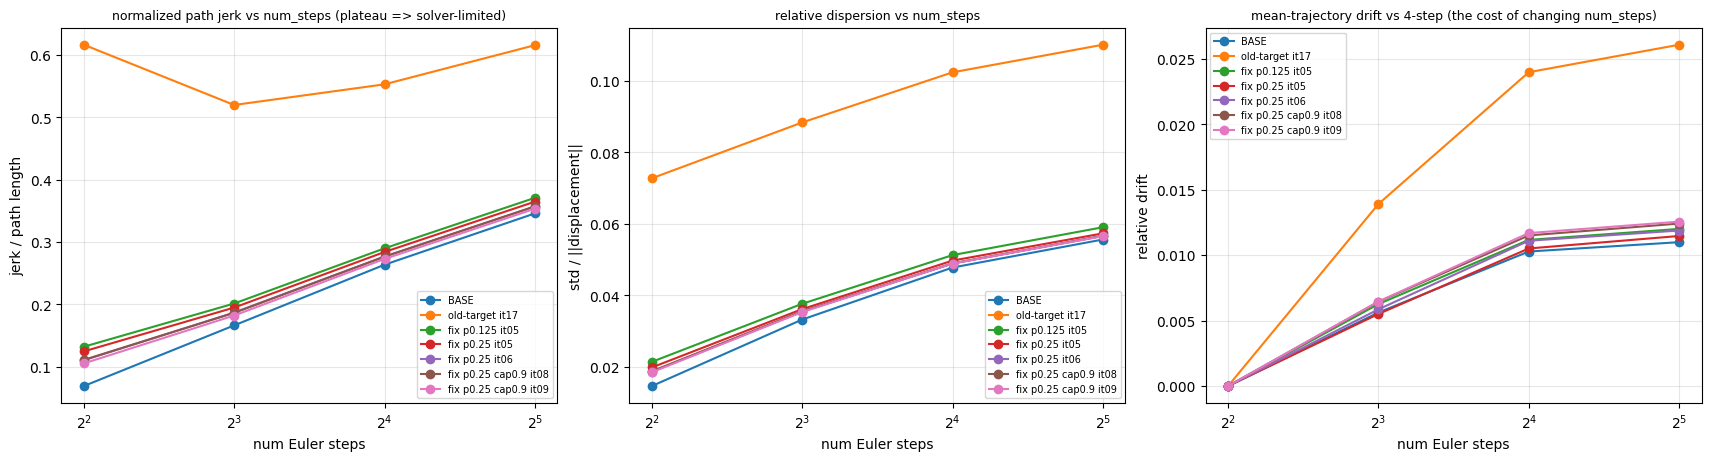

In [11]:
# Cell 13: solver_convergence — sweep num_steps on a shared seed set.
# Cost: n_seeds * sum(steps_list) forwards per checkpoint (25 * 60 = 1500 at the
# defaults). Nothing here runs the simulator or produces a success rate.
def _traj_from_chunk(lab, features, a, eef_key=EEF_KEY):
    """Decode a raw chunk to the integrated EEF path, matching
    TrajectoryVisualizer.add_trajectory (0 prepended + cumsum)."""
    d = lab.decode_raw_actions(a, features.states)
    deltas = d[eef_key][0][:, :3]
    return np.concatenate([np.zeros((1, 3)), np.cumsum(deltas, axis=0)], axis=0), deltas


def solver_convergence(lab, features, label, steps_list=(4, 8, 16, 32), n_seeds=25):
    out = {"label": label, "steps": list(steps_list)}
    per_steps = {}
    for ns in steps_list:
        paths, jerks = [], []
        for s in range(n_seeds):                       # SAME seeds for every ns
            res = lab.denoise(features, seed=s, num_steps=ns)
            pos, deltas = _traj_from_chunk(lab, features, res.action_pred)
            paths.append(pos)
            L = float(np.linalg.norm(deltas, axis=1).sum())
            J = float(np.linalg.norm(np.diff(pos, n=3, axis=0), axis=1).sum())
            jerks.append(J / max(L, 1e-9))
        P = np.stack(paths)                            # (n_seeds, T+1, 3)
        mean_traj = P.mean(axis=0)
        disp = float(np.linalg.norm(mean_traj[-1]))
        per_steps[ns] = {
            "pathjerk": float(np.mean(jerks)),
            "rel_disp": float(np.sqrt(P[:, -1].var(axis=0)).mean() / max(disp, 1e-9)),
            "mean_traj": mean_traj,
            "disp": disp,
        }
    ref = per_steps[steps_list[0]]
    for ns in steps_list:                              # drift vs the 4-step mean
        per_steps[ns]["drift"] = float(
            np.linalg.norm(per_steps[ns]["mean_traj"] - ref["mean_traj"], axis=1).mean()
            / max(ref["disp"], 1e-9))
    out["per_steps"] = per_steps

    print(f"  {'num_steps':>9s} {'pathjerk':>9s} {'vs 4step':>9s} "
          f"{'rel_disp':>9s} {'vs 4step':>9s} {'drift':>8s}")
    j4, d4 = ref["pathjerk"], ref["rel_disp"]
    for ns in steps_list:
        v = per_steps[ns]
        print(f"  {ns:9d} {v['pathjerk']:9.5f} {v['pathjerk'] / max(j4, 1e-12):9.2f} "
              f"{v['rel_disp']:9.4f} {v['rel_disp'] / max(d4, 1e-12):9.2f} "
              f"{v['drift']:8.4f}")
    return out


def run_solver_sweep(obs_path, steps_list=(4, 8, 16, 32), n_seeds=25,
                     include_base=True):
    obs = DenoisingLab.load_observation(obs_path)
    features = lab.encode_features_from_sim_obs(obs)
    print(f"Observation: {obs_path}   ({n_seeds} seeds, shared across num_steps)\n")
    results, ckpt_of = {}, {}
    if include_base:
        print("=" * 90); print("BASE (no LoRA)"); print("=" * 90)
        with disabled_adapters(lab.model.action_head.model):
            results["BASE"] = solver_convergence(lab, features, "BASE",
                                                 steps_list, n_seeds)
        ckpt_of["BASE"] = ""
    for lbl, ckpt_rel in CHECKPOINTS.items():
        print("\n" + "=" * 90); print(f"CHECKPOINT: {lbl}"); print("=" * 90)
        load_lora_checkpoint(lab.model, os.path.join(REPO_ROOT, ckpt_rel))
        results[lbl] = solver_convergence(lab, features, lbl, steps_list, n_seeds)
        ckpt_of[lbl] = os.path.join(REPO_ROOT, ckpt_rel)

    # Data behind the 3-panel figure below.
    runs, sl = list(results), list(steps_list)

    def _per(f):
        return np.array([[results[k]["per_steps"][n][f] for n in sl] for k in runs])

    save_plot_data(
        f"solver_convergence__{os.path.splitext(os.path.basename(obs_path))[0]}",
        meta={"obs_path": obs_path, "ckpt_paths": [ckpt_of[k] for k in runs],
              "n_seeds": n_seeds,
              "arrays": {"pathjerk/rel_disp/drift": "(run, num_steps); the three panels",
                         "disp": "(run, num_steps) ||final point of the seed-mean path||",
                         "mean_traj": "(run, num_steps, timestep, xyz) seed-mean EEF path"}},
        runs=runs, steps=np.array(sl),
        pathjerk=_per("pathjerk"), rel_disp=_per("rel_disp"), drift=_per("drift"),
        disp=_per("disp"), mean_traj=_per("mean_traj"),
    )

    return results


_solver_010 = run_solver_sweep(
    "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
for k, v in _solver_010.items():
    sl = v["steps"]
    axes[0].plot(sl, [v["per_steps"][n]["pathjerk"] for n in sl], "-o", label=k)
    axes[1].plot(sl, [v["per_steps"][n]["rel_disp"] for n in sl], "-o", label=k)
    axes[2].plot(sl, [v["per_steps"][n]["drift"] for n in sl], "-o", label=k)
for ax, ttl, yl in zip(axes,
        ["normalized path jerk vs num_steps (plateau => solver-limited)",
         "relative dispersion vs num_steps",
         "mean-trajectory drift vs 4-step (the cost of changing num_steps)"],
        ["jerk / path length", "std / ||displacement||", "relative drift"]):
    ax.set_title(ttl, fontsize=9); ax.set_xlabel("num Euler steps"); ax.set_ylabel(yl)
    ax.set_xscale("log", base=2); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.show()


## Residual roughness

Per τ-center: the velocity residual `r = v − (a − ε)` along the FM path (`M(r)` is its size,
`HF(r)` its roughness along the horizon, 0 = smooth and 1 = white), the generated chunk's own
roughness (`act_HF`), the implied endpoint's roughness (`HF(a_hat)`), path jerk and the residual
spectrum. One table per observation; the figure after step012 plots both.


In [12]:
# Cell 9: Action-dim layout, read from the CHECKPOINT (self-verifying).
#
# Mirrors processing_gr00t_n1d6.decode_action (:239-246) and
# grpo_server.compute_action_mask (:278): walk this embodiment's action
# modality_keys IN ORDER, take each key's normalized `dim`, accumulate contiguous
# slices. If this checkpoint's layout differs from the expected PandaOmron one,
# you see it in the printout rather than silently masking the wrong columns.
TAG = lab.embodiment_tag.value
_acfg = lab.modality_configs["action"]
_norm = lab.processor.state_action_processor.norm_params[TAG]["action"]

ACTION_HORIZON_VALID = len(_acfg.delta_indices)          # 16 for PandaOmron
_layout, _start = [], 0
for _key in _acfg.modality_keys:
    _d = _norm[_key]["dim"]
    _d = int(_d.item() if hasattr(_d, "item") else _d)
    _layout.append((_key, _start, _start + _d))
    _start += _d
N_VALID_DIMS = _start

# Discrete 0/1 channels — EXCLUDED from every roughness measure. robocasa's
# PandaOmronKeyConverter.unmap_action thresholds both at 0.5, so a grasp and a
# base-mode switch ARE step functions and must stay free to step.
DISCRETE_KEYS = {"gripper_close", "control_mode"}

# base_motion is gated by control_mode (HybridMobileBase makes arm and base
# mutually exclusive), so its roughness can be inert in arm mode. Keep it OUT of
# the default set so the constraint's capacity goes to the channel the plots
# actually show; flip to True to include it and compare.
INCLUDE_BASE_MOTION = False

C_DIMS, C_KEYS = [], []
for _key, _lo, _hi in _layout:
    _short = _key.split(".")[-1]
    if _short in DISCRETE_KEYS:
        continue
    if _short == "base_motion" and not INCLUDE_BASE_MOTION:
        continue
    C_DIMS.extend(range(_lo, _hi))
    C_KEYS.append(_short)

# Measure the FULL valid horizon, not just the executed prefix. Three reasons:
#   1. compute_fm_log_prob masks with action_mask = the full valid rectangle
#      (16x12 here), so ref_mse / the ratio / every advantage already cover all 16
#      steps. Measuring M over 8 would make smooth/M_mean non-comparable to
#      ref_mse/mean.
#   2. 14 second-differences instead of 6 -> less than half the per-row variance,
#      which is what keeps a per-row relu gate from chattering.
#   3. n_action_steps is a DEPLOYMENT knob; the 16-step horizon is a property of
#      the checkpoint (delta_indices). Baking the former into the objective means a
#      later --n_action_steps 16 run executes steps never trained to be smooth.
# The DiT also emits the chunk jointly (self-attention over action tokens), so
# nothing keeps tail degradation out of the head.
H_MEASURE = ACTION_HORIZON_VALID

# Executed prefix — used ONLY to split the diagnostic into head / tail below, so
# we can see empirically whether roughness is uniform in h or tail-concentrated.
N_ACTION_STEPS = 8

# tau_centers: GRPOConfig default (late-biased). Keep in sync with the run.
TAU_CENTERS = [0.0, 0.25, 0.35, 0.5, 0.6, 0.75]

print(f"embodiment={TAG}  valid_horizon={ACTION_HORIZON_VALID}  valid_dims={N_VALID_DIMS}")
print(f"raw model output = ({lab.action_horizon}, {lab.action_dim}) -> valid rectangle "
      f"[:{ACTION_HORIZON_VALID}, :{N_VALID_DIMS}]")
print("\naction dim layout (order comes from the checkpoint, NOT from the repo):")
for _key, _lo, _hi in _layout:
    _short = _key.split(".")[-1]
    _tag = "DISCRETE - excluded" if _short in DISCRETE_KEYS else (
        "excluded (INCLUDE_BASE_MOTION=False)"
        if _short == "base_motion" and not INCLUDE_BASE_MOTION else "in C")
    print(f"  [{_lo:2d}:{_hi:2d}]  {_short:28s} dim={_hi - _lo}  {_tag}")
print(f"\nC = {C_KEYS} -> {len(C_DIMS)} dims: {C_DIMS}")
print(f"h range measured: 0..{H_MEASURE - 1} (FULL valid horizon), "
      f"{max(0, H_MEASURE - 2)} second-differences")
print(f"diagnostic split: head = h<{N_ACTION_STEPS} (executed), "
      f"tail = h>={N_ACTION_STEPS} (discarded at n_action_steps={N_ACTION_STEPS})")
print(f"tau centers: {TAU_CENTERS}")


embodiment=robocasa_panda_omron  valid_horizon=16  valid_dims=12
raw model output = (50, 128) -> valid rectangle [:16, :12]

action dim layout (order comes from the checkpoint, NOT from the repo):
  [ 0: 3]  end_effector_position        dim=3  in C
  [ 3: 6]  end_effector_rotation        dim=3  in C
  [ 6: 7]  gripper_close                dim=1  DISCRETE - excluded
  [ 7:11]  base_motion                  dim=4  excluded (INCLUDE_BASE_MOTION=False)
  [11:12]  control_mode                 dim=1  DISCRETE - excluded

C = ['end_effector_position', 'end_effector_rotation'] -> 6 dims: [0, 1, 2, 3, 4, 5]
h range measured: 0..15 (FULL valid horizon), 14 second-differences
diagnostic split: head = h<8 (executed), tail = h>=8 (discarded at n_action_steps=8)
tau centers: [0.0, 0.25, 0.35, 0.5, 0.6, 0.75]


In [13]:
# Cell 10: measure_roughness — residual spectrum (M, HF) + scale-controlled path jerk.
#
# One pass over seeds computes BOTH families, so this adds no denoise() calls
# beyond the ones it needs:
#   * residual: for each tau, build the FM interpolant x_tau = (1-tau)*eps + tau*a,
#     forward the DiT once, and take r = v_theta - (a - eps). This is exactly the
#     tensor compute_fm_log_prob squares at fm_log_prob.py:253.
#   * path jerk: decode the chunk to EEF deltas, integrate to positions the same
#     way TrajectoryVisualizer.add_trajectory does (0 prepended + cumsum), then
#     report sum(|3rd difference|) / path_length. The NORMALIZATION is the point:
#     LoRA paths are 28-43% longer, so RAW jerk rises mechanically and cannot
#     distinguish "rougher" from "bigger".
#
# Slicing to the valid rectangle happens BEFORE differencing — differencing the
# padded (50, 128) output would straddle the pad boundary and return garbage.
#
# Not batched over seeds on purpose: features has batch 1, and broadcasting a
# batch-1 vl_embeds against batch-S actions in cross-attention is a silent-
# wrongness risk. n_seeds=25 is plenty for a distributional statistic.
import numpy as np
import torch


def _d2(u):
    """Second difference along the horizon axis (axis=1) of an (N, H, D) array."""
    return u[:, 2:] - 2.0 * u[:, 1:-1] + u[:, :-2]


def measure_roughness(lab, features, label, n_seeds=25, tau_centers=None,
                      dims=None, h_measure=None, num_steps=4, eef_key=EEF_KEY):
    tau_centers = TAU_CENTERS if tau_centers is None else tau_centers
    dims = C_DIMS if dims is None else dims
    H = H_MEASURE if h_measure is None else h_measure
    nb = lab.num_timestep_buckets

    per_tau = {tau: {"M": [], "R": [], "M_head": [], "R_head": [],
                     "M_tail": [], "R_tail": [], "M_ahat": [], "R_ahat": []}
               for tau in tau_centers}
    act_M, act_R, path_jerk, path_len = [], [], [], []

    # Head/tail windows for the diagnostic split. _d2 returns (N, H-2, D), so
    # index j covers h in [j, j+2]. "head" = windows entirely inside the executed
    # prefix; "tail" = windows entirely inside the discarded remainder. The two
    # straddling windows belong to neither and are dropped from the split only
    # (never from the full measure).
    he = min(N_ACTION_STEPS, H)
    head_sl, tail_sl = slice(0, max(he - 2, 0)), slice(he, max(H - 2, 0))

    # Full power spectrum of r along h. HF is only a 2-moment SUMMARY of this, and
    # it SATURATES: a residual that is even 50% white already reads HF~0.93, so if
    # the base residual is unstructured error (the null hypothesis for a well-fit
    # regression) HF_base ~ 1 and there is <2.7x headroom before the 8/3 ceiling.
    # The spectrum says directly whether HF is a usable instrument here: flat =
    # white = HF pinned at 1 = use the M cap instead, not the HF hinge.
    spec_acc = np.zeros(H // 2 + 1)
    spec_n = 0

    for s in range(n_seeds):
        res = lab.denoise(features, seed=s, num_steps=num_steps)
        a, eps = res.action_pred, res.initial_noise
        v_target = a - eps                                    # FM velocity target

        # --- roughness of the produced chunk itself (normalized action space) ---
        a_v = a[:, :H, :].float()[:, :, dims]
        act_M.append(a_v.pow(2).mean().item())
        act_R.append(_d2(a_v).pow(2).mean().item())

        # --- scale-controlled jerk of the decoded EEF path (physical units) ---
        d = lab.decode_raw_actions(a, features.states)
        deltas = d[eef_key][0][:, :3]                          # (T, 3)
        pos = np.concatenate([np.zeros((1, 3)), np.cumsum(deltas, axis=0)], axis=0)
        L = float(np.linalg.norm(deltas, axis=1).sum())
        J = float(np.linalg.norm(np.diff(pos, n=3, axis=0), axis=1).sum())
        path_len.append(L)
        path_jerk.append(J / max(L, 1e-9))

        # --- velocity residual at each tau center ---
        for tau in tau_centers:
            x_tau = (1.0 - tau) * eps + tau * a
            # denoise_single_step computes t_cont = step_idx / num_total_steps, so
            # passing num_total_steps = num_timestep_buckets hits tau exactly.
            v, _ = lab.denoise_single_step(features, x_tau, round(tau * nb), nb)
            r = (v - v_target)[:, :H, :].float()[:, :, dims]
            d2r = _d2(r)
            # The model's IMPLIED ENDPOINT, a_hat = x_tau + (1-tau)*v = a + (1-tau)*r.
            # At tau=0, x_tau IS eps, so this evaluation sits ON the sampler's path and
            # a_hat is literally the 1-step Euler endpoint. This is the differentiable
            # quantity CLOSEST to the generated chunk — which matters because the
            # chunk's spectrum (act_HF) degrades far more than the residual's.
            ahat = (x_tau + (1.0 - tau) * v)[:, :H, :].float()[:, :, dims]
            per_tau[tau]["M_ahat"].append(ahat.pow(2).mean().item())
            per_tau[tau]["R_ahat"].append(_d2(ahat).pow(2).mean().item())
            per_tau[tau]["M"].append(r.pow(2).mean().item())
            per_tau[tau]["R"].append(d2r.pow(2).mean().item())
            # pooled over tau: normalized |rfft|^2 along h, averaged over dims
            _p = np.abs(np.fft.rfft(r.cpu().numpy(), axis=1)) ** 2
            spec_acc += (_p / max(_p.sum(axis=1, keepdims=True).mean(), 1e-30)
                         ).mean(axis=(0, 2))
            spec_n += 1
            # head / tail split — diagnostic only, never used by the loss
            if head_sl.stop > head_sl.start:
                per_tau[tau]["M_head"].append(r[:, :he].pow(2).mean().item())
                per_tau[tau]["R_head"].append(d2r[:, head_sl].pow(2).mean().item())
            if tail_sl.stop > tail_sl.start:
                per_tau[tau]["M_tail"].append(r[:, he:].pow(2).mean().item())
                per_tau[tau]["R_tail"].append(d2r[:, tail_sl].pow(2).mean().item())

    def agg(key, tau):
        vals = per_tau[tau][key]
        return float(np.mean(vals)) if vals else float("nan")

    taus = list(tau_centers)
    M = np.array([agg("M", t) for t in taus])
    R = np.array([agg("R", t) for t in taus])
    HF = R / (6.0 * np.maximum(M, 1e-12))          # 0 = smooth, 1 = white in h
    HF_head = (np.array([agg("R_head", t) for t in taus])
               / (6.0 * np.maximum([agg("M_head", t) for t in taus], 1e-12)))
    HF_tail = (np.array([agg("R_tail", t) for t in taus])
               / (6.0 * np.maximum([agg("M_tail", t) for t in taus], 1e-12)))
    HF_ahat = (np.array([agg("R_ahat", t) for t in taus])
               / (6.0 * np.maximum([agg("M_ahat", t) for t in taus], 1e-12)))

    out = {
        "label": label, "taus": taus,
        "M": M, "R": R, "HF": HF,
        "HF_head": HF_head, "HF_tail": HF_tail, "HF_ahat": HF_ahat,
        "HF_ahat_mean": float(np.nanmean(HF_ahat)),
        "M_a": float(np.mean(act_M)),
        "M_mean": float(M.mean()), "HF_mean": float(HF.mean()),
        "HF_head_mean": float(np.nanmean(HF_head)),
        "HF_tail_mean": float(np.nanmean(HF_tail)),
        # the chunk's own spectrum, same normalization
        "act_HF": float(np.mean(act_R) / max(np.mean(act_M), 1e-12) / 6.0),
        "spectrum": spec_acc / max(spec_n, 1),      # length H//2+1, sums to ~1
        "path_jerk": float(np.mean(path_jerk)),
        "path_jerk_p90": float(np.percentile(path_jerk, 90)),
        "path_len": float(np.mean(path_len)),
        "n_seeds": n_seeds,
    }
    print(f"  M(r) mean over tau = {out['M_mean']:.5f}   "
          f"(compare ref_mse/mean in TB)")
    print(f"  HF(r) mean over tau = {out['HF_mean']:.4f}   "
          f"[0=smooth, 1=white]")
    print(f"  HF per tau         = " + "  ".join(f"{t:.2f}:{h:.3f}"
                                                 for t, h in zip(taus, HF)))
    print(f"  HF head/tail       = {out['HF_head_mean']:.4f} (h<{he}) / "
          f"{out['HF_tail_mean']:.4f} (h>={he})   "
          f"[tail/head = {out['HF_tail_mean'] / max(out['HF_head_mean'], 1e-9):.2f}x]")
    print(f"  HF(action chunk)   = {out['act_HF']:.4f}   M(a) = {out['M_a']:.4f}"
          f"   [M(a)/M(r) = {out['M_a'] / max(out['M_mean'], 1e-12):.3g}x]")
    print(f"  HF(a_hat) per tau  = " + "  ".join(
        f"{t:.2f}:{h:.4f}" for t, h in zip(taus, HF_ahat))
          + f"   mean {out['HF_ahat_mean']:.4f}")
    print(f"  path jerk / length = {out['path_jerk']:.5f}  "
          f"(p90 {out['path_jerk_p90']:.5f}), mean path length {out['path_len']:.3f}")
    sp = out["spectrum"]
    print(f"  |rfft(r)|^2 by bin  = " + " ".join(f"{p:.3f}" for p in sp))
    print(f"    flat ({1.0 / len(sp):.3f} each) = white = HF pinned near 1;"
          f"  hi/lo half = {sp[len(sp) // 2:].sum() / max(sp[:len(sp) // 2].sum(), 1e-12):.2f}")
    return out


In [14]:
# Cell 11: run the measurement for the base model + every checkpoint, then print
# the roughness table. Mirrors analyze_all_checkpoints: encode features ONCE (the
# backbone is LoRA-free), run base with the adapters disabled, then load each
# checkpoint in place.
HF_N_SEEDS = 25          # 25 x (4 denoise + 6 probe) forwards per checkpoint


def measure_all_checkpoints(obs_path, n_seeds=HF_N_SEEDS, include_base=True):
    obs = DenoisingLab.load_observation(obs_path)
    features = lab.encode_features_from_sim_obs(obs)
    print(f"Observation: {obs_path}")
    print(f"C = {C_KEYS} ({len(C_DIMS)} dims), h 0..{H_MEASURE - 1}, "
          f"{n_seeds} seeds\n")

    results, ckpt_of = {}, {}
    if include_base:
        print("=" * 90); print("BASE (no LoRA)"); print("=" * 90)
        with disabled_adapters(lab.model.action_head.model):
            results["BASE"] = measure_roughness(lab, features, "BASE",
                                                n_seeds=n_seeds)
        ckpt_of["BASE"] = ""
    for label, ckpt_rel in CHECKPOINTS.items():
        print("\n" + "=" * 90); print(f"CHECKPOINT: {label}"); print("=" * 90)
        load_lora_checkpoint(lab.model, os.path.join(REPO_ROOT, ckpt_rel))
        results[label] = measure_roughness(lab, features, label, n_seeds=n_seeds)
        ckpt_of[label] = os.path.join(REPO_ROOT, ckpt_rel)

    # Data behind this observation's row of the Cell 12 figure (HF / M vs tau, roughness
    # bars, spectrum) plus the other per-run measurements printed above.
    runs = list(results)
    keys = ("M", "R", "HF", "HF_head", "HF_tail", "HF_ahat", "spectrum",
            "M_a", "act_HF", "path_jerk", "path_jerk_p90", "path_len")
    save_plot_data(
        f"roughness__{os.path.splitext(os.path.basename(obs_path))[0]}",
        meta={"obs_path": obs_path, "ckpt_paths": [ckpt_of[k] for k in runs],
              "n_seeds": n_seeds, "C_KEYS": C_KEYS, "h_measure": H_MEASURE,
              "arrays": {"M/R/HF/HF_head/HF_tail/HF_ahat": "(run, tau)",
                         "spectrum": "(run, freq_bin) |rfft(r)|^2 along h",
                         "M_a/act_HF/path_jerk/path_jerk_p90/path_len": "(run,)"}},
        runs=runs, taus=np.array(results[runs[0]]["taus"]),
        **{k: np.stack([np.asarray(results[r][k]) for r in runs]) for k in keys},
    )
    return features, results


def report(results, obs_name=""):
    base = results.get("BASE")
    print("\n" + "=" * 90)
    print(f"ROUGHNESS TABLE — {obs_name}")
    print("=" * 90)
    print(f"{'run':24s} {'M(r)':>9s} {'M ratio':>8s} {'HF(r)':>7s} "
          f"{'HF ratio':>9s} {'HFahat':>8s} {'ahat r':>7s} "
          f"{'act_HF':>8s} {'aHF r':>7s} {'pathjerk':>9s} {'pj ratio':>9s}")
    for k, v in results.items():
        mr = v["M_mean"] / base["M_mean"] if base else float("nan")
        hr = v["HF_mean"] / base["HF_mean"] if base else float("nan")
        pr = v["path_jerk"] / base["path_jerk"] if base else float("nan")
        ar = v["HF_ahat_mean"] / base["HF_ahat_mean"] if base else float("nan")
        cr = v["act_HF"] / max(base["act_HF"], 1e-12) if base else float("nan")
        print(f"{k:24s} {v['M_mean']:9.5f} {mr:8.2f} {v['HF_mean']:7.4f} "
              f"{hr:9.2f} {v['HF_ahat_mean']:8.4f} {ar:7.2f} "
              f"{v['act_HF']:8.4f} {cr:7.1f} {v['path_jerk']:9.5f} {pr:9.2f}")



_feat_010, res_010 = measure_all_checkpoints(
    "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz")
report(res_010, "ep000_step010.npz")


Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz
C = ['end_effector_position', 'end_effector_rotation'] (6 dims), h 0..15, 25 seeds

BASE (no LoRA)


  M(r) mean over tau = 0.00047   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.6185   [0=smooth, 1=white]
  HF per tau         = 0.00:0.557  0.25:0.569  0.35:0.634  0.50:0.618  0.60:0.690  0.75:0.643
  HF head/tail       = 0.6248 (h<8) / 0.6232 (h>=8)   [tail/head = 1.00x]
  HF(action chunk)   = 0.0014   M(a) = 0.0432   [M(a)/M(r) = 92.8x]
  HF(a_hat) per tau  = 0.00:0.0016  0.25:0.0010  0.35:0.0013  0.50:0.0004  0.60:0.0003  0.75:0.0015   mean 0.0010
  path jerk / length = 0.06893  (p90 0.08257), mean path length 6.260
  |rfft(r)|^2 by bin  = 0.251 0.186 0.116 0.101 0.077 0.077 0.067 0.066 0.060
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.53

CHECKPOINT: old-target it17
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017


  M(r) mean over tau = 0.00285   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.9370   [0=smooth, 1=white]
  HF per tau         = 0.00:0.917  0.25:0.959  0.35:0.969  0.50:0.994  0.60:1.021  0.75:0.763
  HF head/tail       = 0.9448 (h<8) / 0.9227 (h>=8)   [tail/head = 0.98x]
  HF(action chunk)   = 0.1216   M(a) = 0.0717   [M(a)/M(r) = 25.2x]
  HF(a_hat) per tau  = 0.00:0.2834  0.25:0.2605  0.35:0.2335  0.50:0.1948  0.60:0.1586  0.75:0.1081   mean 0.2065
  path jerk / length = 0.61660  (p90 0.72434), mean path length 8.307
  |rfft(r)|^2 by bin  = 0.206 0.087 0.091 0.109 0.107 0.111 0.095 0.096 0.100
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 1.03

CHECKPOINT: fix p0.125 it05
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2/iter_0005


  M(r) mean over tau = 0.00018   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.4802   [0=smooth, 1=white]
  HF per tau         = 0.00:0.646  0.25:0.393  0.35:0.338  0.50:0.340  0.60:0.535  0.75:0.630
  HF head/tail       = 0.5133 (h<8) / 0.4531 (h>=8)   [tail/head = 0.88x]
  HF(action chunk)   = 0.0050   M(a) = 0.0437   [M(a)/M(r) = 240x]
  HF(a_hat) per tau  = 0.00:0.0125  0.25:0.0075  0.35:0.0052  0.50:0.0044  0.60:0.0030  0.75:0.0050   mean 0.0063
  path jerk / length = 0.13204  (p90 0.15298), mean path length 6.416
  |rfft(r)|^2 by bin  = 0.363 0.220 0.089 0.064 0.054 0.057 0.051 0.053 0.049
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.36

CHECKPOINT: fix p0.25 it05
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0005


  M(r) mean over tau = 0.00018   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.5129   [0=smooth, 1=white]
  HF per tau         = 0.00:0.681  0.25:0.427  0.35:0.357  0.50:0.379  0.60:0.573  0.75:0.660
  HF head/tail       = 0.5338 (h<8) / 0.4857 (h>=8)   [tail/head = 0.91x]
  HF(action chunk)   = 0.0045   M(a) = 0.0444   [M(a)/M(r) = 253x]
  HF(a_hat) per tau  = 0.00:0.0117  0.25:0.0071  0.35:0.0046  0.50:0.0036  0.60:0.0025  0.75:0.0045   mean 0.0056
  path jerk / length = 0.12457  (p90 0.14443), mean path length 6.468
  |rfft(r)|^2 by bin  = 0.348 0.215 0.088 0.068 0.060 0.060 0.054 0.056 0.053
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.39

CHECKPOINT: fix p0.25 it06
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0006


  M(r) mean over tau = 0.00020   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.5110   [0=smooth, 1=white]
  HF per tau         = 0.00:0.555  0.25:0.389  0.35:0.436  0.50:0.422  0.60:0.596  0.75:0.669
  HF head/tail       = 0.5195 (h<8) / 0.5001 (h>=8)   [tail/head = 0.96x]
  HF(action chunk)   = 0.0036   M(a) = 0.0448   [M(a)/M(r) = 230x]
  HF(a_hat) per tau  = 0.00:0.0073  0.25:0.0042  0.35:0.0027  0.50:0.0024  0.60:0.0016  0.75:0.0036   mean 0.0036
  path jerk / length = 0.11028  (p90 0.12819), mean path length 6.462
  |rfft(r)|^2 by bin  = 0.327 0.223 0.094 0.072 0.060 0.060 0.055 0.057 0.050
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.39

CHECKPOINT: fix p0.25 cap0.9 it08
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPAR

  M(r) mean over tau = 0.00019   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.4878   [0=smooth, 1=white]
  HF per tau         = 0.00:0.533  0.25:0.376  0.35:0.394  0.50:0.398  0.60:0.577  0.75:0.650
  HF head/tail       = 0.4762 (h<8) / 0.4966 (h>=8)   [tail/head = 1.04x]
  HF(action chunk)   = 0.0036   M(a) = 0.0449   [M(a)/M(r) = 231x]
  HF(a_hat) per tau  = 0.00:0.0071  0.25:0.0044  0.35:0.0028  0.50:0.0025  0.60:0.0017  0.75:0.0036   mean 0.0037
  path jerk / length = 0.11089  (p90 0.12930), mean path length 6.437
  |rfft(r)|^2 by bin  = 0.342 0.220 0.097 0.071 0.056 0.057 0.058 0.053 0.046
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.37

CHECKPOINT: fix p0.25 cap0.9 it09
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPAR

  M(r) mean over tau = 0.00021   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.4918   [0=smooth, 1=white]
  HF per tau         = 0.00:0.540  0.25:0.391  0.35:0.398  0.50:0.416  0.60:0.592  0.75:0.613
  HF head/tail       = 0.4919 (h<8) / 0.4867 (h>=8)   [tail/head = 0.99x]
  HF(action chunk)   = 0.0032   M(a) = 0.0446   [M(a)/M(r) = 217x]
  HF(a_hat) per tau  = 0.00:0.0068  0.25:0.0040  0.35:0.0025  0.50:0.0021  0.60:0.0014  0.75:0.0032   mean 0.0034
  path jerk / length = 0.10525  (p90 0.12363), mean path length 6.424
  |rfft(r)|^2 by bin  = 0.339 0.218 0.095 0.074 0.059 0.053 0.056 0.056 0.050
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.38
Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v4.5/roughness__ep000_step010.npz

ROUGHNESS TABLE — ep000_step010.npz
run                           M(r)  M ratio   HF(r)  HF ratio   HFahat  ahat r   act_HF   aHF r  pathjerk  pj ratio
BASE                       0.00047     1.00  

Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz
C = ['end_effector_position', 'end_effector_rotation'] (6 dims), h 0..15, 25 seeds

BASE (no LoRA)


  M(r) mean over tau = 0.00072   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.3565   [0=smooth, 1=white]
  HF per tau         = 0.00:0.302  0.25:0.348  0.35:0.440  0.50:0.429  0.60:0.553  0.75:0.068
  HF head/tail       = 0.4168 (h<8) / 0.3254 (h>=8)   [tail/head = 0.78x]
  HF(action chunk)   = 0.0065   M(a) = 0.0094   [M(a)/M(r) = 13x]
  HF(a_hat) per tau  = 0.00:0.0067  0.25:0.0047  0.35:0.0057  0.50:0.0013  0.60:0.0008  0.75:0.0068   mean 0.0043
  path jerk / length = 0.11987  (p90 0.14707), mean path length 3.646
  |rfft(r)|^2 by bin  = 0.351 0.255 0.086 0.068 0.057 0.049 0.046 0.043 0.043
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.31

CHECKPOINT: old-target it17
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017


  M(r) mean over tau = 0.00437   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.7252   [0=smooth, 1=white]
  HF per tau         = 0.00:0.743  0.25:0.838  0.35:0.844  0.50:0.891  0.60:0.974  0.75:0.060
  HF head/tail       = 0.8699 (h<8) / 0.6520 (h>=8)   [tail/head = 0.75x]
  HF(action chunk)   = 0.3096   M(a) = 0.0295   [M(a)/M(r) = 6.74x]
  HF(a_hat) per tau  = 0.00:0.6136  0.25:0.5695  0.35:0.5294  0.50:0.4599  0.60:0.3873  0.75:0.2505   mean 0.4684
  path jerk / length = 0.95073  (p90 1.09829), mean path length 5.739
  |rfft(r)|^2 by bin  = 0.228 0.108 0.084 0.104 0.102 0.102 0.089 0.092 0.090
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.91

CHECKPOINT: fix p0.125 it05
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2/iter_0005


  M(r) mean over tau = 0.00044   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.1673   [0=smooth, 1=white]
  HF per tau         = 0.00:0.253  0.25:0.120  0.35:0.129  0.50:0.134  0.60:0.314  0.75:0.054
  HF head/tail       = 0.2066 (h<8) / 0.1502 (h>=8)   [tail/head = 0.73x]
  HF(action chunk)   = 0.0252   M(a) = 0.0102   [M(a)/M(r) = 23.3x]
  HF(a_hat) per tau  = 0.00:0.0631  0.25:0.0362  0.35:0.0266  0.50:0.0233  0.60:0.0168  0.75:0.0246   mean 0.0318
  path jerk / length = 0.24237  (p90 0.29539), mean path length 3.776
  |rfft(r)|^2 by bin  = 0.536 0.247 0.055 0.035 0.029 0.026 0.024 0.024 0.023
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.15

CHECKPOINT: fix p0.25 it05
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0005


  M(r) mean over tau = 0.00044   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.1688   [0=smooth, 1=white]
  HF per tau         = 0.00:0.245  0.25:0.116  0.35:0.131  0.50:0.138  0.60:0.329  0.75:0.054
  HF head/tail       = 0.2146 (h<8) / 0.1490 (h>=8)   [tail/head = 0.69x]
  HF(action chunk)   = 0.0235   M(a) = 0.0102   [M(a)/M(r) = 23.3x]
  HF(a_hat) per tau  = 0.00:0.0626  0.25:0.0363  0.35:0.0254  0.50:0.0206  0.60:0.0151  0.75:0.0228   mean 0.0305
  path jerk / length = 0.23315  (p90 0.28273), mean path length 3.771
  |rfft(r)|^2 by bin  = 0.529 0.249 0.056 0.035 0.029 0.026 0.025 0.026 0.024
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.15

CHECKPOINT: fix p0.25 it06
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25/iter_0006


  M(r) mean over tau = 0.00050   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.1581   [0=smooth, 1=white]
  HF per tau         = 0.00:0.147  0.25:0.100  0.35:0.144  0.50:0.160  0.60:0.353  0.75:0.044
  HF head/tail       = 0.2054 (h<8) / 0.1344 (h>=8)   [tail/head = 0.65x]
  HF(action chunk)   = 0.0190   M(a) = 0.0102   [M(a)/M(r) = 20.4x]
  HF(a_hat) per tau  = 0.00:0.0425  0.25:0.0230  0.35:0.0156  0.50:0.0145  0.60:0.0106  0.75:0.0187   mean 0.0208
  path jerk / length = 0.20946  (p90 0.25459), mean path length 3.767
  |rfft(r)|^2 by bin  = 0.542 0.244 0.055 0.036 0.029 0.024 0.025 0.023 0.022
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.14

CHECKPOINT: fix p0.25 cap0.9 it08
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPA

  M(r) mean over tau = 0.00053   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.1462   [0=smooth, 1=white]
  HF per tau         = 0.00:0.140  0.25:0.094  0.35:0.135  0.50:0.136  0.60:0.331  0.75:0.041
  HF head/tail       = 0.1853 (h<8) / 0.1249 (h>=8)   [tail/head = 0.67x]
  HF(action chunk)   = 0.0200   M(a) = 0.0103   [M(a)/M(r) = 19.4x]
  HF(a_hat) per tau  = 0.00:0.0441  0.25:0.0251  0.35:0.0170  0.50:0.0161  0.60:0.0116  0.75:0.0196   mean 0.0222
  path jerk / length = 0.21651  (p90 0.25967), mean path length 3.747
  |rfft(r)|^2 by bin  = 0.554 0.244 0.053 0.034 0.027 0.023 0.022 0.021 0.022
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.13

CHECKPOINT: fix p0.25 cap0.9 it09
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10/overfit_step10_v6_lr5e-5_plam0.125_nlam0_nojitterpair_jitterfix_loclip0.005_rel1.0_hiclip0.2_kll0.1_klb0.1_noPAWS_iterrenorm_BMPARD_3epoch_gs12_ng4_mb128_IAG0.3_postreopen2_res3_plam0.25_res7_BMPA

  M(r) mean over tau = 0.00055   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.1510   [0=smooth, 1=white]
  HF per tau         = 0.00:0.148  0.25:0.096  0.35:0.138  0.50:0.146  0.60:0.346  0.75:0.032
  HF head/tail       = 0.1939 (h<8) / 0.1287 (h>=8)   [tail/head = 0.66x]
  HF(action chunk)   = 0.0187   M(a) = 0.0103   [M(a)/M(r) = 18.9x]
  HF(a_hat) per tau  = 0.00:0.0453  0.25:0.0245  0.35:0.0161  0.50:0.0150  0.60:0.0107  0.75:0.0182   mean 0.0216
  path jerk / length = 0.21126  (p90 0.25427), mean path length 3.769
  |rfft(r)|^2 by bin  = 0.540 0.249 0.056 0.035 0.028 0.025 0.024 0.022 0.022
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.14
Plot data saved: /home/ubuntu/my_Isaac-GR00T/scripts/denoising_lab/notebooks/plot_data_v4.5/roughness__ep000_step012.npz

ROUGHNESS TABLE — ep000_step012.npz
run                           M(r)  M ratio   HF(r)  HF ratio   HFahat  ahat r   act_HF   aHF r  pathjerk  pj ratio
BASE                       0.00072     1.00 

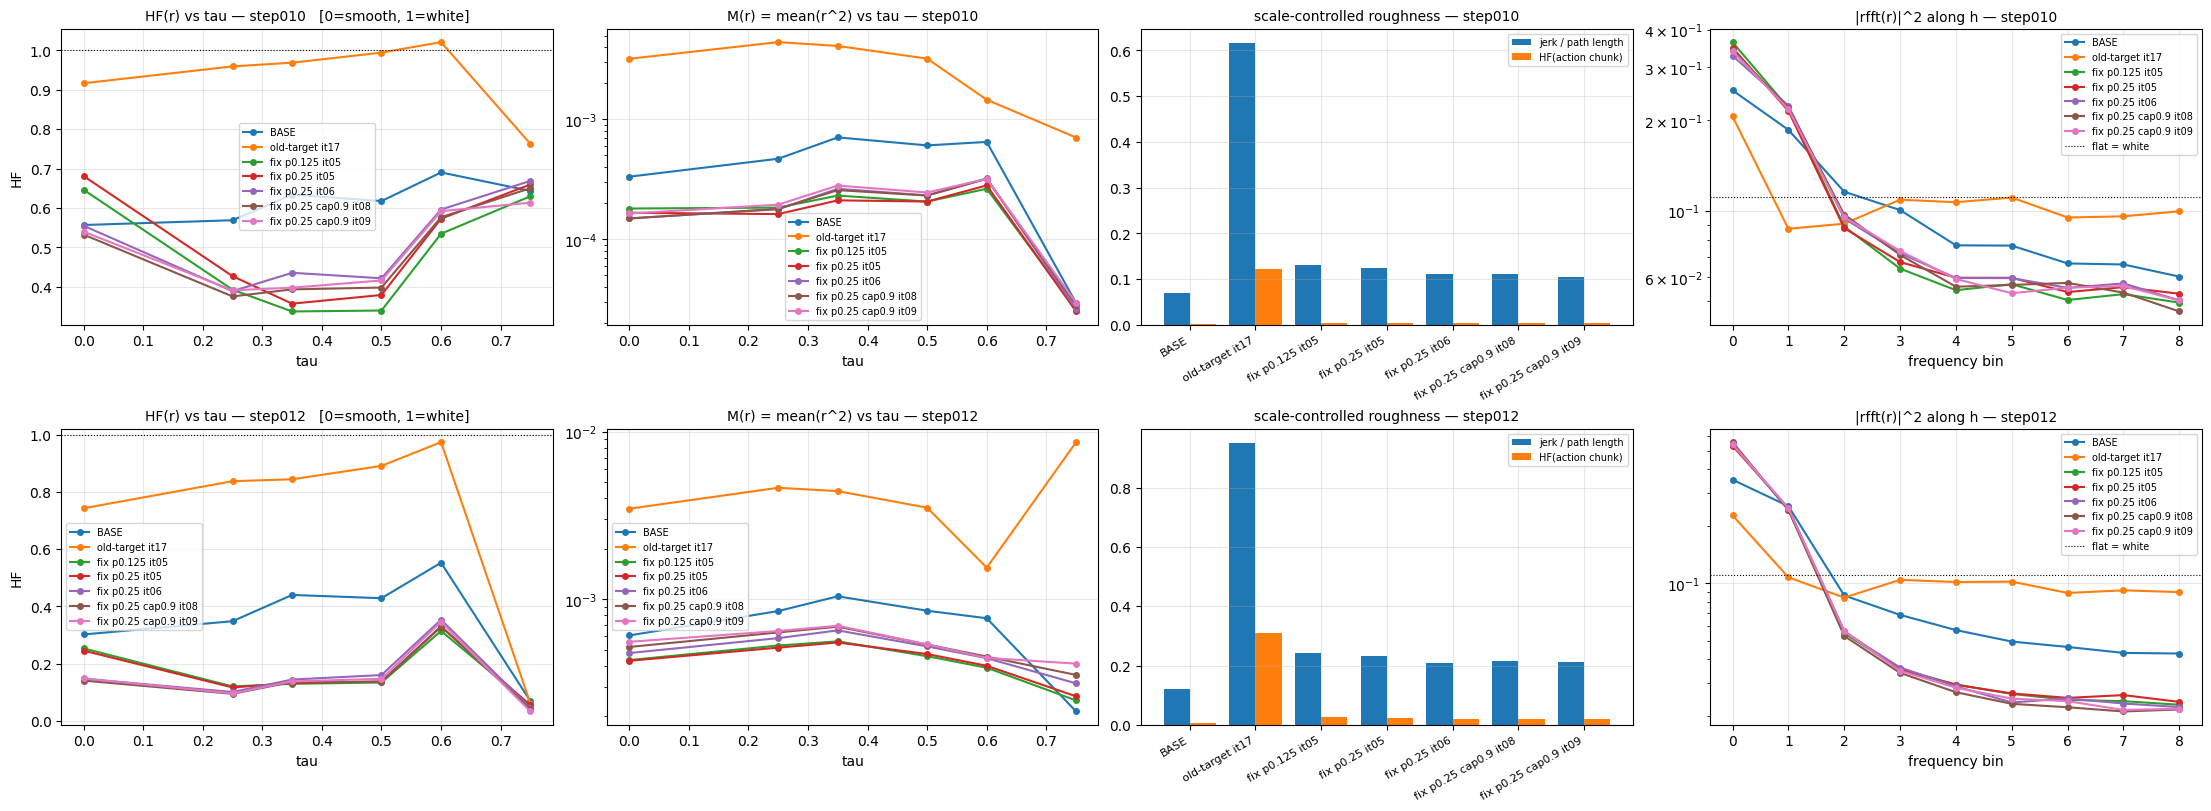

In [15]:
# Cell 12: same measurement for step012, then plot HF(tau) and M(tau) for both
# observations. HF is the new signal; M is the sanity check against ref_mse/mean.
_feat_012, res_012 = measure_all_checkpoints(
    "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz")
report(res_012, "ep000_step012.npz")

fig, axes = plt.subplots(2, 4, figsize=(22, 8), constrained_layout=True)
for row, (res, name) in enumerate([(res_010, "step010"), (res_012, "step012")]):
    for k, v in res.items():
        axes[row, 0].plot(v["taus"], v["HF"], "-o", label=k, markersize=4)
        axes[row, 1].plot(v["taus"], v["M"], "-o", label=k, markersize=4)
    axes[row, 0].set_title(f"HF(r) vs tau — {name}   [0=smooth, 1=white]", fontsize=10)
    axes[row, 0].set_xlabel("tau"); axes[row, 0].set_ylabel("HF")
    axes[row, 0].axhline(1.0, color="k", ls=":", lw=0.8)
    axes[row, 1].set_title(f"M(r) = mean(r^2) vs tau — {name}", fontsize=10)
    axes[row, 1].set_xlabel("tau"); axes[row, 1].set_yscale("log")
    labels = list(res.keys())
    x = np.arange(len(labels))
    axes[row, 2].bar(x - 0.2, [res[k]["path_jerk"] for k in labels], 0.4,
                     label="jerk / path length")
    axes[row, 2].bar(x + 0.2, [res[k]["act_HF"] for k in labels], 0.4,
                     label="HF(action chunk)")
    axes[row, 2].set_xticks(x)
    axes[row, 2].set_xticklabels([l.replace("iter_", "it") for l in labels],
                                 rotation=30, ha="right", fontsize=8)
    axes[row, 2].set_title(f"scale-controlled roughness — {name}", fontsize=10)
    for k, v in res.items():
        sp = v["spectrum"]
        axes[row, 3].plot(np.arange(len(sp)), sp, "-o", label=k, markersize=4)
    axes[row, 3].axhline(1.0 / len(res["BASE"]["spectrum"]), color="k", ls=":", lw=0.8,
                         label="flat = white")
    axes[row, 3].set_title(f"|rfft(r)|^2 along h — {name}", fontsize=10)
    axes[row, 3].set_xlabel("frequency bin"); axes[row, 3].set_yscale("log")
    for c in range(4):
        axes[row, c].grid(True, alpha=0.3)
        axes[row, c].legend(fontsize=7)
plt.show()
